In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pennylane import numpy as np

qubits=[qbt for qbt in range(1,6)]

accuracy_unbiased=[0.9211,0.9211,0.9561,0.8947,0.8684]
precision_unbiased=[0.9170,0.9137,0.9510,0.8836,0.8631]
recall_unbiased=[0.9127,0.9177,0.9554,0.8968,0.8512]
f1score_unbiased=[0.9147,0.9156,0.9531,0.8890,0.8564]

accuracy_biased=[0.9211,0.9474,0.9649,0.9649,0.8684]
precision_biased=[0.9170,0.9403,0.9623,0.9737,0.8598]
recall_biased=[0.9127,0.9484,0.9623,0.9524,0.8562]
f1score_biased=[0.9147,0.9440,0.9623,0.9615,0.8579]

number_of_params_unbiased=[3*1,6*6,9*8,12*10,15*3]
number_of_params_biased=[(3*1 + 1), (6*7 + 1), (9*8 + 1), (12*9 + 1),(15*5 + 1)]

best_epochs_unbiased=[86,110,254,219,243]
best_epochs_biased=[84,126,292,285,300]


# Set Seaborn theme
sns.set_theme(style="whitegrid", palette="muted")
palette = sns.color_palette("husl", 4)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

def plot_metrics_with_values(df, title, filename):
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=16)

    for i, metric in enumerate(metrics):
        row, col = divmod(i, 2)
        ax = axs[row, col]
        
        # Plot Line
        sns.lineplot(data=df, x='Qubits', y=metric, marker='o', ax=ax, color=palette[i], linewidth=2.5)
        ax.fill_between(df['Qubits'], df[metric], alpha=0.1, color=palette[i])
        
        # Add Annotations
        for x, y in zip(df['Qubits'], df[metric]):
            ax.annotate(
                f'{y:.4f}', 
                xy=(x, y), 
                xytext=(0, -15), # Offset: 10 points above
                textcoords='offset points',
                ha='center', 
                fontsize=9,
                color='black',
                fontweight='bold'
            )
        
        ax.set_title(metric, fontsize=14)
        ax.set_xlabel('Number of Qubits')
        ax.set_ylabel('Score of best VQC')
        ax.set_xticks(qubits)
        ax.set_ylim(0.8, 1.00) # Increased slightly to 1.05 to fit the text labels at the top

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(filename,dpi=300, bbox_inches='tight')
    plt.show()

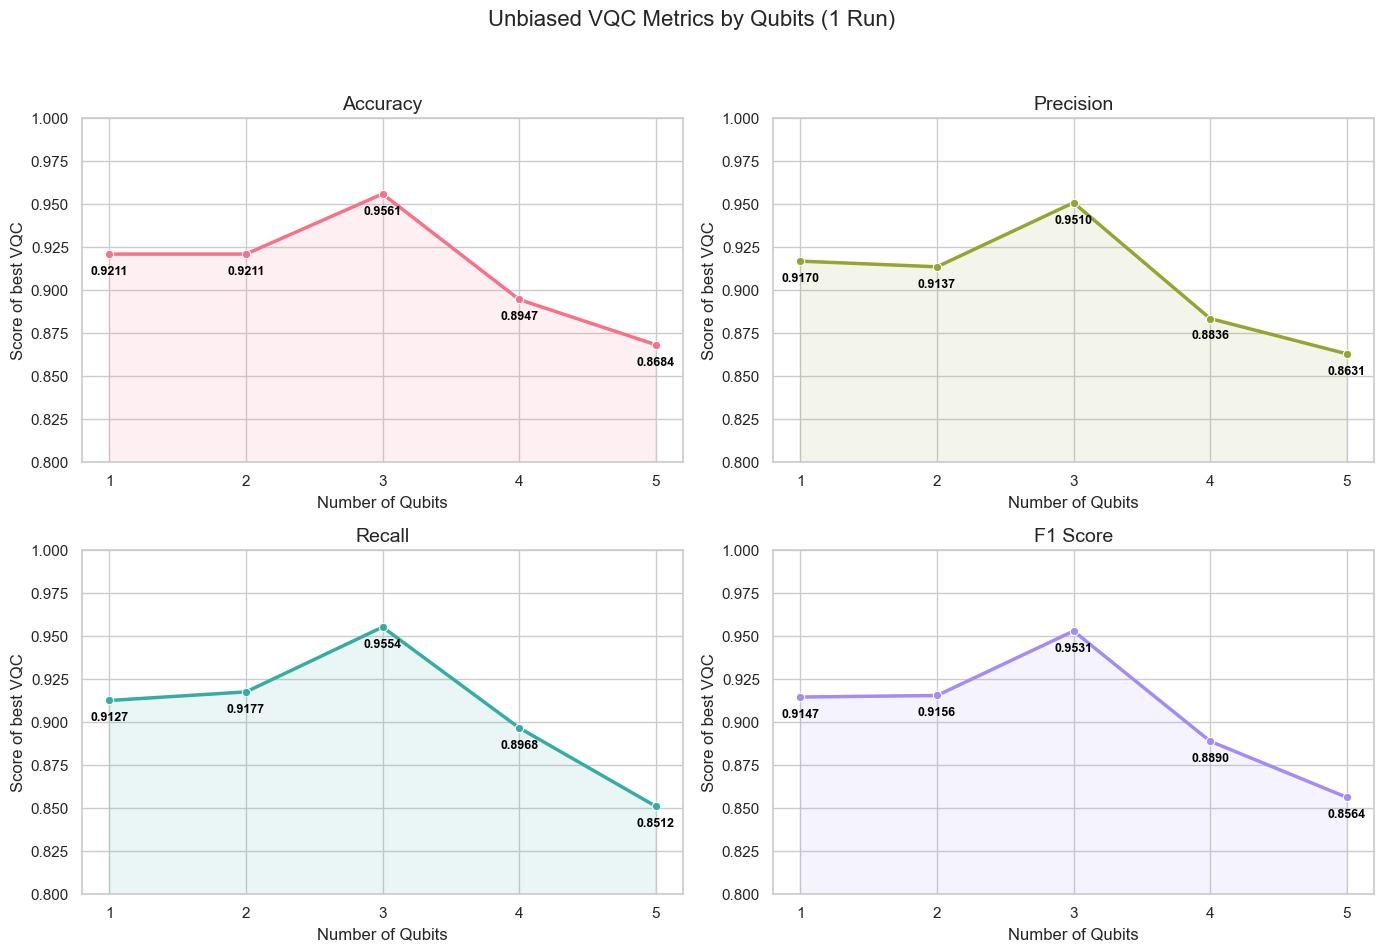

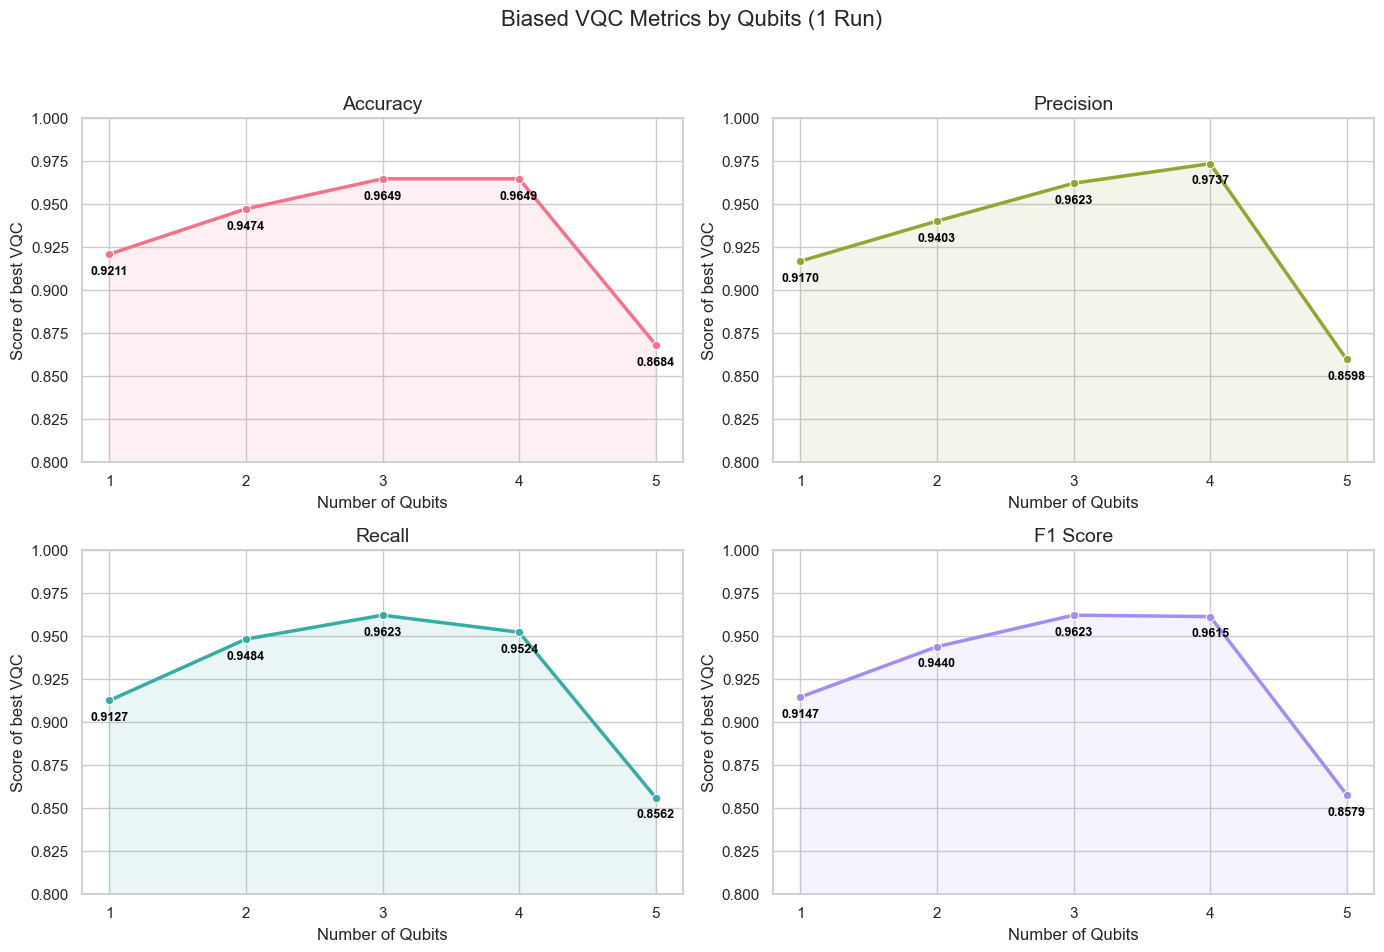

In [2]:
# Create DataFrames
df_unbiased = pd.DataFrame({
    'Qubits': qubits,
    'Accuracy': accuracy_unbiased,
    'Precision': precision_unbiased,
    'Recall': recall_unbiased,
    'F1 Score': f1score_unbiased
})

df_biased = pd.DataFrame({
    'Qubits': qubits,
    'Accuracy': accuracy_biased,
    'Precision': precision_biased,
    'Recall': recall_biased,
    'F1 Score': f1score_biased
})


# 1. Plot Unbiased
plot_metrics_with_values(df_unbiased, 'Unbiased VQC Metrics by Qubits (1 Run)', './images/1_run/final_comparison/1_run_unbiased_metrics_labeled.png')

# 2. Plot Biased
plot_metrics_with_values(df_biased, 'Biased VQC Metrics by Qubits (1 Run)', './images/1_run/final_comparison/1_run_biased_metrics_labeled.png')

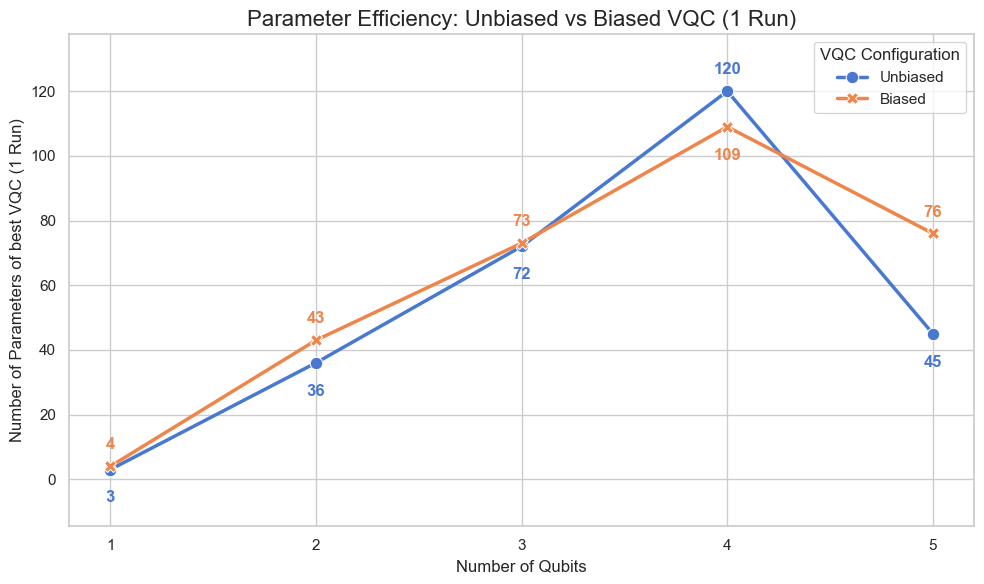

In [3]:
number_of_params_unbiased=[3*1,6*6,9*8,12*10,15*3]
number_of_params_biased=[(3*1 + 1), (6*7 + 1), (9*8 + 1), (12*9 + 1),(15*5 + 1)]


# Create a combined DataFrame
df_unbiased = pd.DataFrame({
    'Qubits': qubits,
    'Parameters': number_of_params_unbiased,
    'VQC Type': 'Unbiased'
})

df_biased = pd.DataFrame({
    'Qubits': qubits,
    'Parameters': number_of_params_biased,
    'VQC Type': 'Biased'
})

df_combined = pd.concat([df_unbiased, df_biased])

# Set Seaborn theme
sns.set_theme(style="whitegrid", palette="muted")
colors = sns.color_palette("muted")

# Create the plot
plt.figure(figsize=(10, 6))
plt.title('Parameter Efficiency: Unbiased vs Biased VQC (1 Run)', fontsize=16)

# Plot the lines
ax = sns.lineplot(
    data=df_combined, 
    x='Qubits', 
    y='Parameters', 
    hue='VQC Type', 
    style='VQC Type', 
    markers=True, 
    dashes=False,
    linewidth=2.5,
    markersize=9
)

# --- Dynamic Annotation Logic ---

for i, x in enumerate(qubits):
    y_unbiased = number_of_params_unbiased[i]
    y_biased = number_of_params_biased[i]
    
    # 1. Handle Unbiased Label
    # If Unbiased is higher (or equal), put label ABOVE. Else put BELOW.
    if y_unbiased >= y_biased:
        xytext_u = (0, 10)
        va_u = 'bottom'
    else:
        xytext_u = (0, -15)
        va_u = 'top'
        
    ax.annotate(
        f'{y_unbiased}', 
        xy=(x, y_unbiased), 
        xytext=xytext_u,
        textcoords='offset points',
        ha='center', va=va_u,
        color=colors[0], # Blue
        fontweight='bold'
    )

    # 2. Handle Biased Label
    # If Biased is higher, put label ABOVE. Else put BELOW.
    if y_biased > y_unbiased:
        xytext_b = (0, 10)
        va_b = 'bottom'
    else:
        xytext_b = (0, -15)
        va_b = 'top'

    ax.annotate(
        f'{y_biased}', 
        xy=(x, y_biased), 
        xytext=xytext_b,
        textcoords='offset points',
        ha='center', va=va_b,
        color=colors[1], # Orange
        fontweight='bold'
    )

plt.xlabel('Number of Qubits', fontsize=12)
plt.ylabel('Number of Parameters of best VQC (1 Run)', fontsize=12)
plt.xticks(qubits)
plt.legend(title='VQC Configuration', fontsize=11, title_fontsize=12)

# Adjust y-margin to ensure labels don't get cut off
plt.margins(y=0.15)

plt.tight_layout()
plt.savefig('./images/1_run/final_comparison/1_run_vqc_params_comparison.png',dpi=300, bbox_inches='tight')
plt.show()

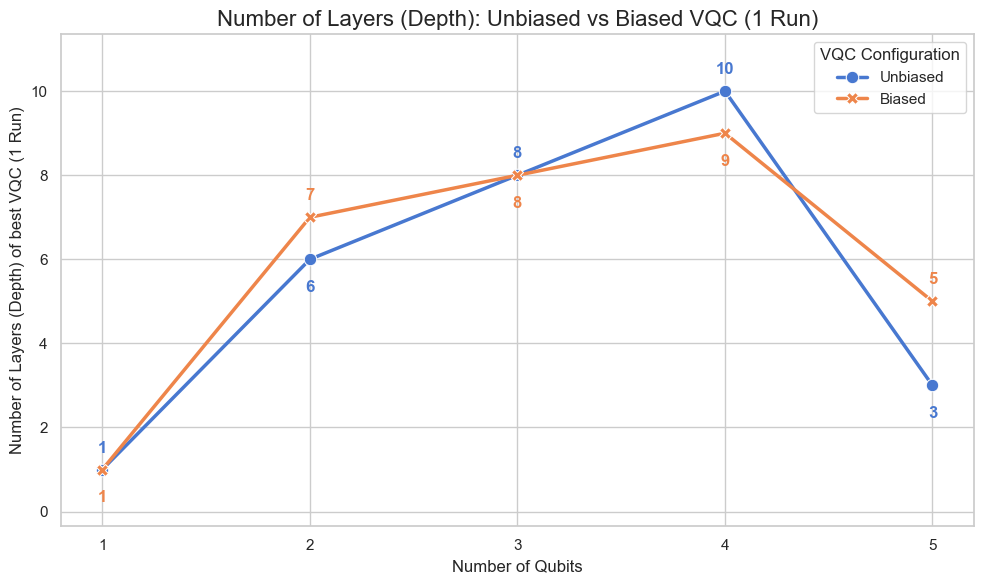

In [4]:
depth_unbiased=[1,6,8,10,3]
depth_biased=[1,7,8,9,5]


# Create a combined DataFrame
df_unbiased = pd.DataFrame({
    'Qubits': qubits,
    'Depth': depth_unbiased,
    'VQC Type': 'Unbiased'
})

df_biased = pd.DataFrame({
    'Qubits': qubits,
    'Depth': depth_biased,
    'VQC Type': 'Biased'
})

df_combined = pd.concat([df_unbiased, df_biased])

# Set Seaborn theme
sns.set_theme(style="whitegrid", palette="muted")
colors = sns.color_palette("muted")

# Create the plot
plt.figure(figsize=(10, 6))
plt.title('Number of Layers (Depth): Unbiased vs Biased VQC (1 Run)', fontsize=16)

# Plot the lines
ax = sns.lineplot(
    data=df_combined, 
    x='Qubits', 
    y='Depth', 
    hue='VQC Type', 
    style='VQC Type', 
    markers=True, 
    dashes=False,
    linewidth=2.5,
    markersize=9
)

# --- Dynamic Annotation Logic ---

for i, x in enumerate(qubits):
    y_unbiased = depth_unbiased[i]
    y_biased = depth_biased[i]
    
    # 1. Handle Unbiased Label
    # If Unbiased is higher (or equal), put label ABOVE. Else put BELOW.
    if y_unbiased >= y_biased:
        xytext_u = (0, 10)
        va_u = 'bottom'
    else:
        xytext_u = (0, -15)
        va_u = 'top'
        
    ax.annotate(
        f'{y_unbiased}', 
        xy=(x, y_unbiased), 
        xytext=xytext_u,
        textcoords='offset points',
        ha='center', va=va_u,
        color=colors[0], # Blue
        fontweight='bold'
    )

    # 2. Handle Biased Label
    # If Biased is higher, put label ABOVE. Else put BELOW.
    if y_biased > y_unbiased:
        xytext_b = (0, 10)
        va_b = 'bottom'
    else:
        xytext_b = (0, -15)
        va_b = 'top'

    ax.annotate(
        f'{y_biased}', 
        xy=(x, y_biased), 
        xytext=xytext_b,
        textcoords='offset points',
        ha='center', va=va_b,
        color=colors[1], # Orange
        fontweight='bold'
    )

plt.xlabel('Number of Qubits', fontsize=12)
plt.ylabel('Number of Layers (Depth) of best VQC (1 Run)', fontsize=12)
plt.xticks(qubits)
plt.legend(title='VQC Configuration', fontsize=11, title_fontsize=12)

# Adjust y-margin to ensure labels don't get cut off
plt.margins(y=0.15)

plt.tight_layout()
plt.savefig('./images/1_run/final_comparison/1_run_vqc_depth_comparison.png',dpi=300, bbox_inches='tight')
plt.show()

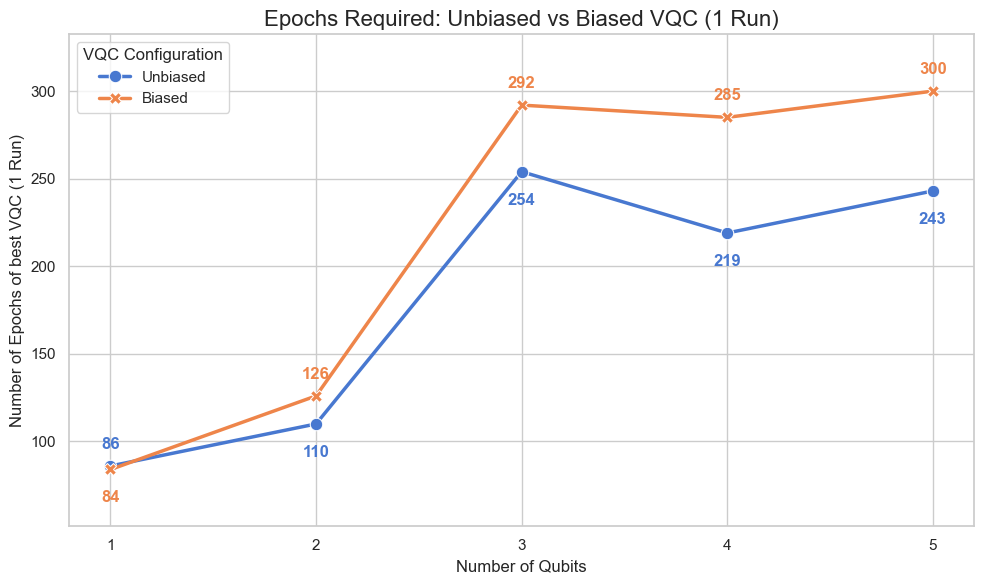

In [5]:
# Create a combined DataFrame
df_unbiased = pd.DataFrame({
    'Qubits': qubits,
    'Epochs': best_epochs_unbiased,
    'VQC Type': 'Unbiased'
})

df_biased = pd.DataFrame({
    'Qubits': qubits,
    'Epochs': best_epochs_biased,
    'VQC Type': 'Biased'
})

df_combined = pd.concat([df_unbiased, df_biased])

# Set Seaborn theme
sns.set_theme(style="whitegrid", palette="muted")
colors = sns.color_palette("muted")

# Create the plot
plt.figure(figsize=(10, 6))
plt.title('Epochs Required: Unbiased vs Biased VQC (1 Run)', fontsize=16)

# Plot the lines
ax = sns.lineplot(
    data=df_combined, 
    x='Qubits', 
    y='Epochs', 
    hue='VQC Type', 
    style='VQC Type', 
    markers=True, 
    dashes=False,
    linewidth=2.5,
    markersize=9
)

# --- Dynamic Annotation Logic ---

for i, x in enumerate(qubits):
    y_unbiased = best_epochs_unbiased[i]
    y_biased = best_epochs_biased[i]
    
    # 1. Handle Unbiased Label
    # If Unbiased is higher (or equal), put label ABOVE. Else put BELOW.
    if y_unbiased >= y_biased:
        xytext_u = (0, 10)
        va_u = 'bottom'
    else:
        xytext_u = (0, -15)
        va_u = 'top'
        
    ax.annotate(
        f'{y_unbiased}', 
        xy=(x, y_unbiased), 
        xytext=xytext_u,
        textcoords='offset points',
        ha='center', va=va_u,
        color=colors[0], # Blue
        fontweight='bold'
    )

    # 2. Handle Biased Label
    # If Biased is higher, put label ABOVE. Else put BELOW.
    if y_biased > y_unbiased:
        xytext_b = (0, 10)
        va_b = 'bottom'
    else:
        xytext_b = (0, -15)
        va_b = 'top'

    ax.annotate(
        f'{y_biased}', 
        xy=(x, y_biased), 
        xytext=xytext_b,
        textcoords='offset points',
        ha='center', va=va_b,
        color=colors[1], # Orange
        fontweight='bold'
    )

plt.xlabel('Number of Qubits', fontsize=12)
plt.ylabel('Number of Epochs of best VQC (1 Run)', fontsize=12)
plt.xticks(qubits)
plt.legend(title='VQC Configuration', fontsize=11, title_fontsize=12)

# Adjust y-margin to ensure labels don't get cut off
plt.margins(y=0.15)

plt.tight_layout()
plt.savefig('./images/1_run/final_comparison/1_run_vqc_epochs_comparison.png',dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# Metrics of the best VQC after 10 Runs

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pennylane import numpy as np

qubits=[qbt for qbt in range(1,6)]

accuracy_unbiased=[0.9211,0.9474,0.9561,0.9649,0.8860]
precision_unbiased=[0.9170,0.9480,0.9483,0.9672,0.8744]
recall_unbiased=[0.9127,0.9385,0.9603,0.9573,0.8899]
f1score_unbiased=[0.9147,0.9429,0.9535,0.9619,0.8802]

accuracy_biased=[0.9211,0.9561,0.9561,0.9561,0.8860]
precision_biased=[0.9170,0.9510,0.9605,0.9551,0.8764]
recall_biased=[0.9127,0.9554,0.9454,0.9504,0.8800]
f1score_biased=[0.9147,0.9531,0.9521,0.9526,0.8781]

number_of_params_unbiased=[3*1,6*6,9*5,12*15,15*20] # num_of_param * num_of_layers
number_of_params_biased=[(3*1 + 1), (6*6 + 1), (9*8 + 1), (12*15 + 1),(15*10 + 1)] # num_of_param * num_of_layers + 1

best_epochs_unbiased=[86,94,234,179,321]
best_epochs_biased=[84,75,201,255,198]


# Set Seaborn theme
sns.set_theme(style="whitegrid", palette="muted")
palette = sns.color_palette("husl", 4)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

def plot_metrics_with_values(df, title, filename):
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=16)

    for i, metric in enumerate(metrics):
        row, col = divmod(i, 2)
        ax = axs[row, col]
        
        # Plot Line
        sns.lineplot(data=df, x='Qubits', y=metric, marker='o', ax=ax, color=palette[i], linewidth=2.5)
        ax.fill_between(df['Qubits'], df[metric], alpha=0.1, color=palette[i])
        
        # Add Annotations
        for x, y in zip(df['Qubits'], df[metric]):
            ax.annotate(
                f'{y:.4f}', 
                xy=(x, y), 
                xytext=(0, -15), # Offset: 10 points above
                textcoords='offset points',
                ha='center', 
                fontsize=9,
                color='black',
                fontweight='bold'
            )
        
        ax.set_title(metric, fontsize=14)
        ax.set_xlabel('Number of Qubits')
        ax.set_ylabel('Score of best VQC')
        ax.set_xticks(qubits)
        ax.set_ylim(0.8, 1.00) # Increased slightly to 1.05 to fit the text labels at the top

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(filename,dpi=300, bbox_inches='tight')
    plt.show()

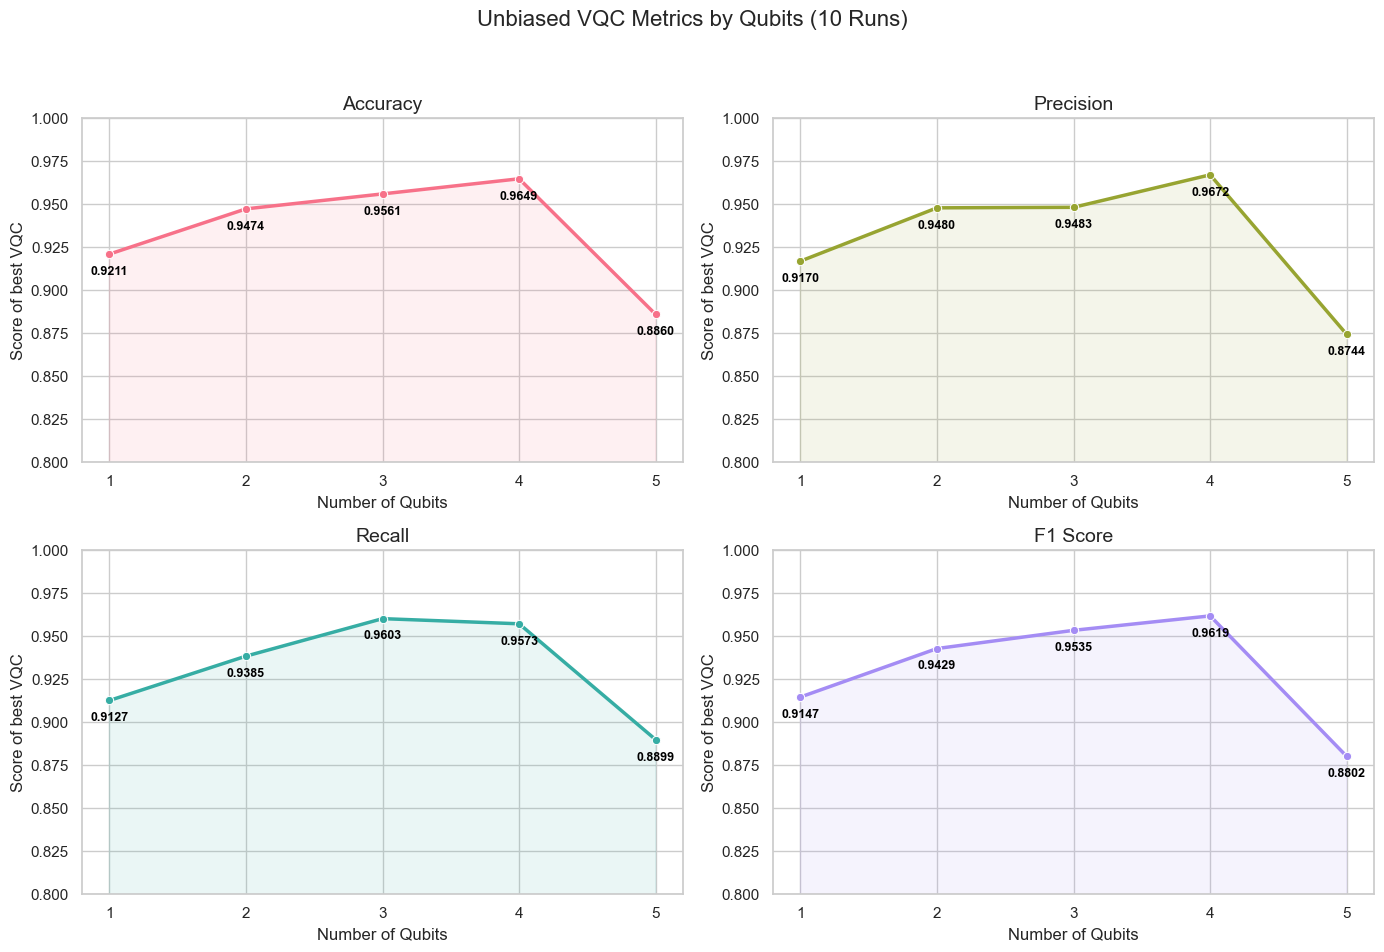

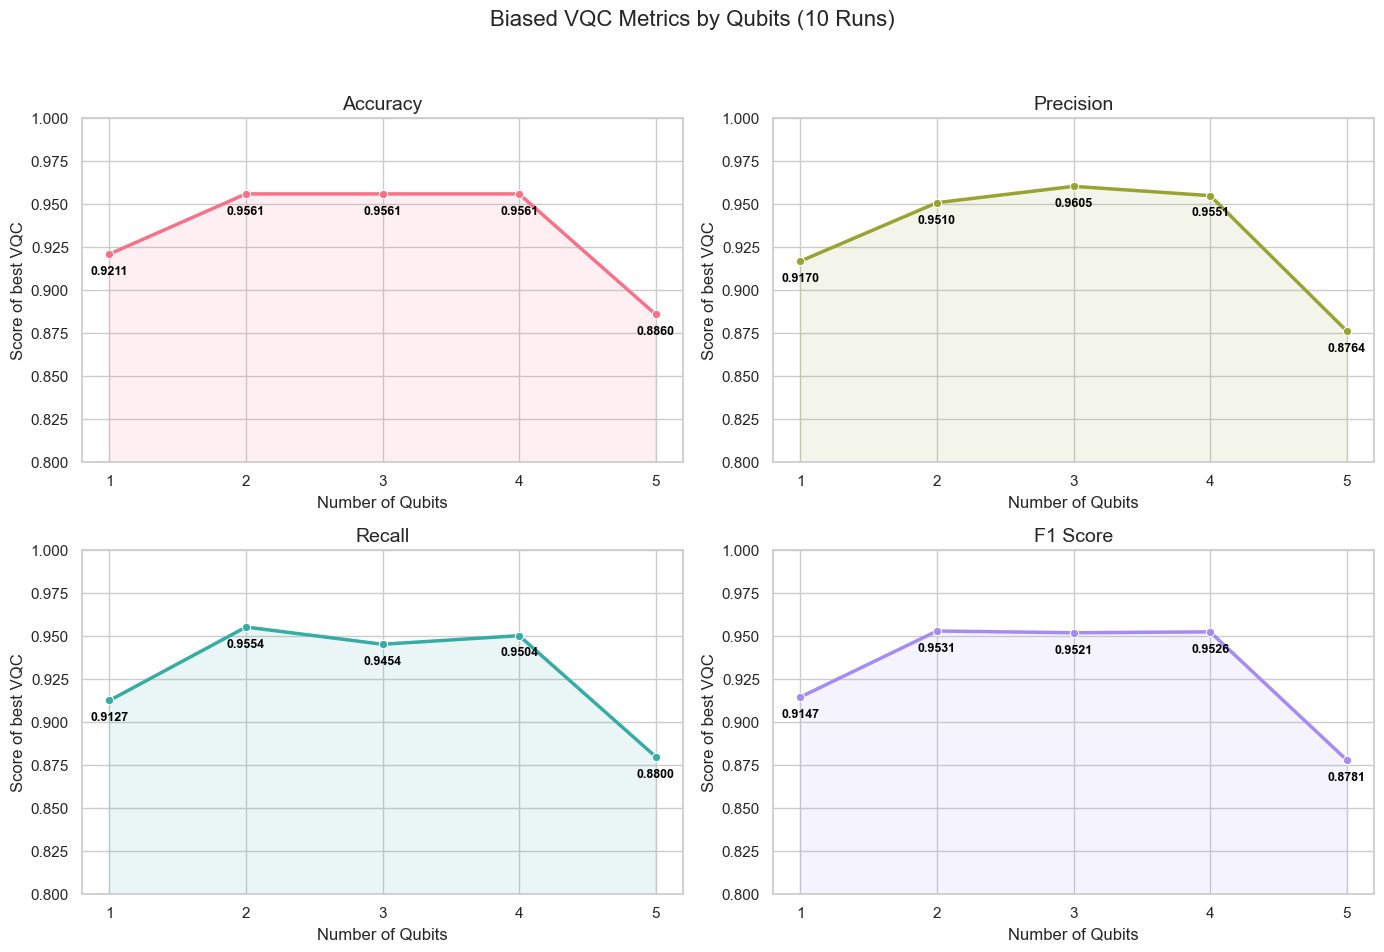

In [7]:
# Metrics of the best VQC after 10 Runs

# Create DataFrames
df_unbiased = pd.DataFrame({
    'Qubits': qubits,
    'Accuracy': accuracy_unbiased,
    'Precision': precision_unbiased,
    'Recall': recall_unbiased,
    'F1 Score': f1score_unbiased
})

df_biased = pd.DataFrame({
    'Qubits': qubits,
    'Accuracy': accuracy_biased,
    'Precision': precision_biased,
    'Recall': recall_biased,
    'F1 Score': f1score_biased
})


# 1. Plot Unbiased
plot_metrics_with_values(df_unbiased, 'Unbiased VQC Metrics by Qubits (10 Runs)', './images/10_runs/final_comparison/10_runs_unbiased_metrics_labeled.png')

# 2. Plot Biased
plot_metrics_with_values(df_biased, 'Biased VQC Metrics by Qubits (10 Runs)', './images/10_runs/final_comparison/10_runs_biased_metrics_labeled.png')

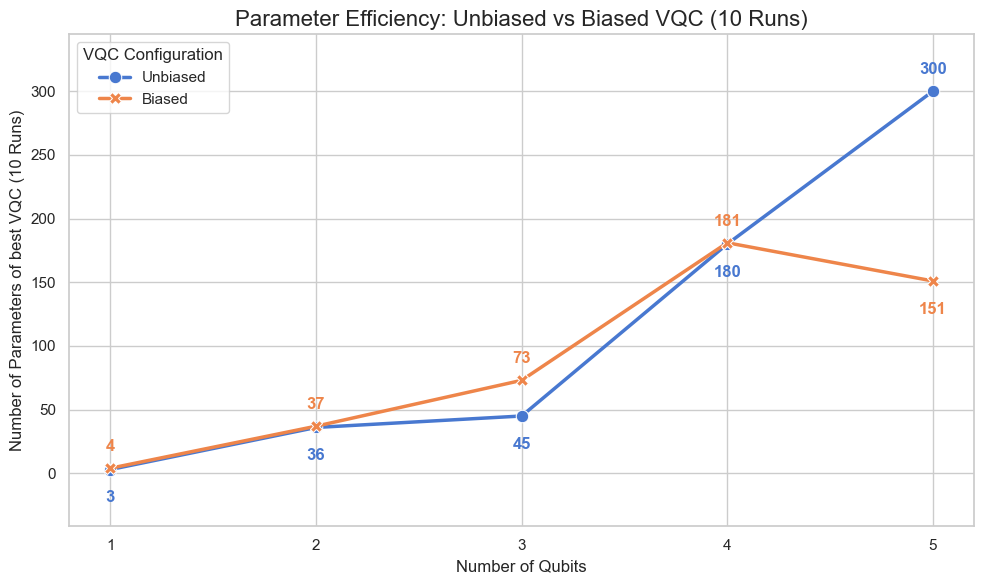

In [8]:
# Metrics of the best VQC after 10 Runs


# Create a combined DataFrame
df_unbiased = pd.DataFrame({
    'Qubits': qubits,
    'Parameters': number_of_params_unbiased,
    'VQC Type': 'Unbiased'
})

df_biased = pd.DataFrame({
    'Qubits': qubits,
    'Parameters': number_of_params_biased,
    'VQC Type': 'Biased'
})

df_combined = pd.concat([df_unbiased, df_biased])

# Set Seaborn theme
sns.set_theme(style="whitegrid", palette="muted")
colors = sns.color_palette("muted")

# Create the plot
plt.figure(figsize=(10, 6))
plt.title('Parameter Efficiency: Unbiased vs Biased VQC (10 Runs)', fontsize=16)

# Plot the lines
ax = sns.lineplot(
    data=df_combined, 
    x='Qubits', 
    y='Parameters', 
    hue='VQC Type', 
    style='VQC Type', 
    markers=True, 
    dashes=False,
    linewidth=2.5,
    markersize=9
)

# --- Dynamic Annotation Logic ---

for i, x in enumerate(qubits):
    y_unbiased = number_of_params_unbiased[i]
    y_biased = number_of_params_biased[i]
    
    # 1. Handle Unbiased Label
    # If Unbiased is higher (or equal), put label ABOVE. Else put BELOW.
    if y_unbiased >= y_biased:
        xytext_u = (0, 10)
        va_u = 'bottom'
    else:
        xytext_u = (0, -15)
        va_u = 'top'
        
    ax.annotate(
        f'{y_unbiased}', 
        xy=(x, y_unbiased), 
        xytext=xytext_u,
        textcoords='offset points',
        ha='center', va=va_u,
        color=colors[0], # Blue
        fontweight='bold'
    )

    # 2. Handle Biased Label
    # If Biased is higher, put label ABOVE. Else put BELOW.
    if y_biased > y_unbiased:
        xytext_b = (0, 10)
        va_b = 'bottom'
    else:
        xytext_b = (0, -15)
        va_b = 'top'

    ax.annotate(
        f'{y_biased}', 
        xy=(x, y_biased), 
        xytext=xytext_b,
        textcoords='offset points',
        ha='center', va=va_b,
        color=colors[1], # Orange
        fontweight='bold'
    )

plt.xlabel('Number of Qubits', fontsize=12)
plt.ylabel('Number of Parameters of best VQC (10 Runs)', fontsize=12)
plt.xticks(qubits)
plt.legend(title='VQC Configuration', fontsize=11, title_fontsize=12)

# Adjust y-margin to ensure labels don't get cut off
plt.margins(y=0.15)

plt.tight_layout()
plt.savefig('./images/10_runs/final_comparison/10_runs_vqc_params_comparison.png',dpi=300, bbox_inches='tight')
plt.show()

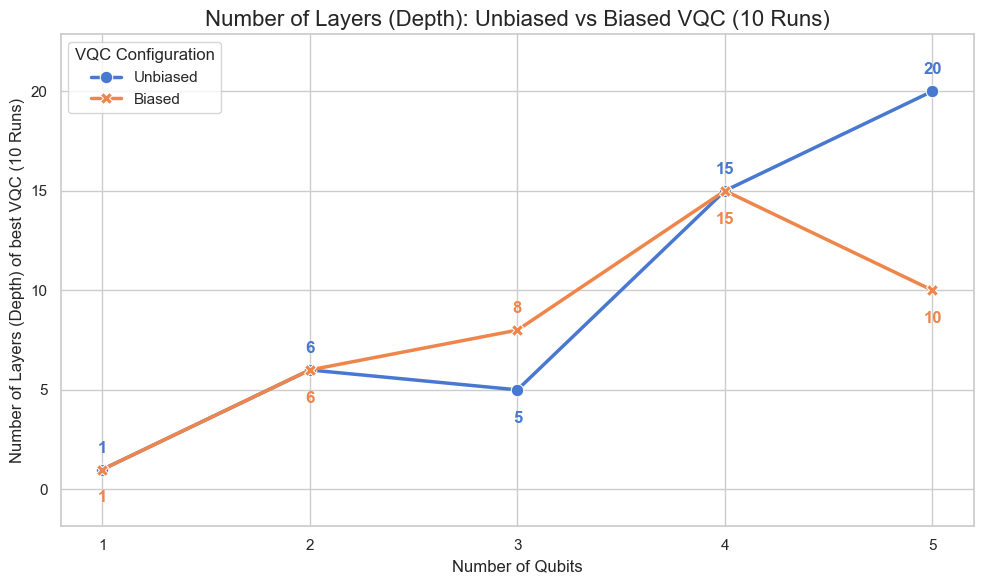

In [9]:
# Metrics of the best VQC after 10 RUNS

depth_unbiased=[1,6,5,15,20]
depth_biased=[1,6,8,15,10]


# Create a combined DataFrame
df_unbiased = pd.DataFrame({
    'Qubits': qubits,
    'Depth': depth_unbiased,
    'VQC Type': 'Unbiased'
})

df_biased = pd.DataFrame({
    'Qubits': qubits,
    'Depth': depth_biased,
    'VQC Type': 'Biased'
})

df_combined = pd.concat([df_unbiased, df_biased])

# Set Seaborn theme
sns.set_theme(style="whitegrid", palette="muted")
colors = sns.color_palette("muted")

# Create the plot
plt.figure(figsize=(10, 6))
plt.title('Number of Layers (Depth): Unbiased vs Biased VQC (10 Runs)', fontsize=16)

# Plot the lines
ax = sns.lineplot(
    data=df_combined, 
    x='Qubits', 
    y='Depth', 
    hue='VQC Type', 
    style='VQC Type', 
    markers=True, 
    dashes=False,
    linewidth=2.5,
    markersize=9
)

# --- Dynamic Annotation Logic ---

for i, x in enumerate(qubits):
    y_unbiased = depth_unbiased[i]
    y_biased = depth_biased[i]
    
    # 1. Handle Unbiased Label
    # If Unbiased is higher (or equal), put label ABOVE. Else put BELOW.
    if y_unbiased >= y_biased:
        xytext_u = (0, 10)
        va_u = 'bottom'
    else:
        xytext_u = (0, -15)
        va_u = 'top'
        
    ax.annotate(
        f'{y_unbiased}', 
        xy=(x, y_unbiased), 
        xytext=xytext_u,
        textcoords='offset points',
        ha='center', va=va_u,
        color=colors[0], # Blue
        fontweight='bold'
    )

    # 2. Handle Biased Label
    # If Biased is higher, put label ABOVE. Else put BELOW.
    if y_biased > y_unbiased:
        xytext_b = (0, 10)
        va_b = 'bottom'
    else:
        xytext_b = (0, -15)
        va_b = 'top'

    ax.annotate(
        f'{y_biased}', 
        xy=(x, y_biased), 
        xytext=xytext_b,
        textcoords='offset points',
        ha='center', va=va_b,
        color=colors[1], # Orange
        fontweight='bold'
    )

plt.xlabel('Number of Qubits', fontsize=12)
plt.ylabel('Number of Layers (Depth) of best VQC (10 Runs)', fontsize=12)
plt.xticks(qubits)
plt.legend(title='VQC Configuration', fontsize=11, title_fontsize=12)

# Adjust y-margin to ensure labels don't get cut off
plt.margins(y=0.15)

plt.tight_layout()
plt.savefig('./images/10_runs/final_comparison/10_runs_vqc_depth_comparison.png',dpi=300, bbox_inches='tight')
plt.show()

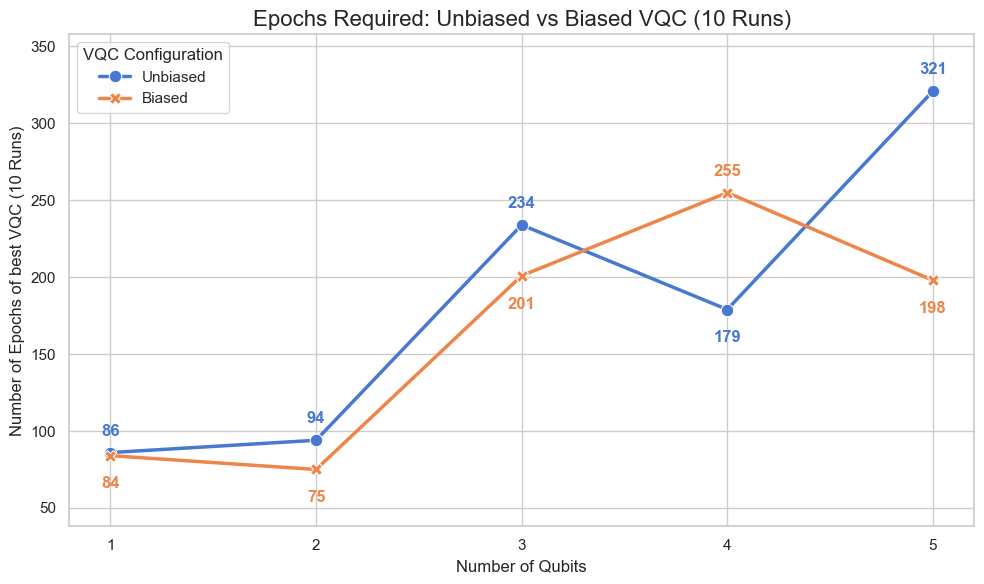

In [10]:
# Metrics of the best VQC after 10 RUNS
# Create a combined DataFrame
df_unbiased = pd.DataFrame({
    'Qubits': qubits,
    'Epochs': best_epochs_unbiased,
    'VQC Type': 'Unbiased'
})

df_biased = pd.DataFrame({
    'Qubits': qubits,
    'Epochs': best_epochs_biased,
    'VQC Type': 'Biased'
})

df_combined = pd.concat([df_unbiased, df_biased])

# Set Seaborn theme
sns.set_theme(style="whitegrid", palette="muted")
colors = sns.color_palette("muted")

# Create the plot
plt.figure(figsize=(10, 6))
plt.title('Epochs Required: Unbiased vs Biased VQC (10 Runs)', fontsize=16)

# Plot the lines
ax = sns.lineplot(
    data=df_combined, 
    x='Qubits', 
    y='Epochs', 
    hue='VQC Type', 
    style='VQC Type', 
    markers=True, 
    dashes=False,
    linewidth=2.5,
    markersize=9
)

# --- Dynamic Annotation Logic ---

for i, x in enumerate(qubits):
    y_unbiased = best_epochs_unbiased[i]
    y_biased = best_epochs_biased[i]
    
    # 1. Handle Unbiased Label
    # If Unbiased is higher (or equal), put label ABOVE. Else put BELOW.
    if y_unbiased >= y_biased:
        xytext_u = (0, 10)
        va_u = 'bottom'
    else:
        xytext_u = (0, -15)
        va_u = 'top'
        
    ax.annotate(
        f'{y_unbiased}', 
        xy=(x, y_unbiased), 
        xytext=xytext_u,
        textcoords='offset points',
        ha='center', va=va_u,
        color=colors[0], # Blue
        fontweight='bold'
    )

    # 2. Handle Biased Label
    # If Biased is higher, put label ABOVE. Else put BELOW.
    if y_biased > y_unbiased:
        xytext_b = (0, 10)
        va_b = 'bottom'
    else:
        xytext_b = (0, -15)
        va_b = 'top'

    ax.annotate(
        f'{y_biased}', 
        xy=(x, y_biased), 
        xytext=xytext_b,
        textcoords='offset points',
        ha='center', va=va_b,
        color=colors[1], # Orange
        fontweight='bold'
    )

plt.xlabel('Number of Qubits', fontsize=12)
plt.ylabel('Number of Epochs of best VQC (10 Runs)', fontsize=12)
plt.xticks(qubits)
plt.legend(title='VQC Configuration', fontsize=11, title_fontsize=12)

# Adjust y-margin to ensure labels don't get cut off
plt.margins(y=0.15)

plt.tight_layout()
plt.savefig('./images/10_runs/final_comparison/10_runs_vqc_epochs_comparison.png',dpi=300, bbox_inches='tight')
plt.show()

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def load_and_visualize(biased_path, unbiased_path, n_qubits,save_location):
    # --- 1. Load Data ---
    try:
        biased_dict = np.load(biased_path, allow_pickle=True).item()
        unbiased_dict = np.load(unbiased_path, allow_pickle=True).item()
    except FileNotFoundError:
        print(f"Error: Files not found. Please ensure {biased_path} and {unbiased_path} are present.")
        biased_dict = {}
        unbiased_dict = {}

    # --- 2. Process Data ---
    data_list = []
    perf_metrics = ['Accuracy', 'F1', 'Precision', 'Recall']
    eff_metrics = ['Best Epoch', 'Training Time']
    all_target_metrics = perf_metrics + eff_metrics

    if biased_dict and unbiased_dict:
        for classifier_name, d in [('Biased', biased_dict), ('Unbiased', unbiased_dict)]:
            for layer, metrics_data in d.items():
                for metric in all_target_metrics:
                    if metric in metrics_data:
                        mean_val = np.mean(metrics_data[metric])
                        data_list.append({
                            'Layer': layer,
                            'Metric': metric,
                            'Type': classifier_name,
                            'Score': mean_val,
                            'Heatmap_Label': f"{metric}-{classifier_name}"
                        })

    df = pd.DataFrame(data_list)
    df = df.sort_values(by='Layer')

    # --- 3. Visualization: Trend Curves with Collision-Free Labels ---
    sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    markers = {'Biased': 'o', 'Unbiased': 'X'}
    
    # Standard Seaborn colors: Biased (first) -> Blue (C0), Unbiased (second) -> Orange (C1)
    colors = {'Biased': 'C0', 'Unbiased': 'C1'}

    for i, metric in enumerate(all_target_metrics):
        ax = axes[i]
        metric_data = df[df['Metric'] == metric]
        
        # 1. Plot the lines
        sns.lineplot(
            data=metric_data,
            x='Layer',
            y='Score',
            hue='Type',
            style='Type',
            markers=markers,
            dashes=False,
            linewidth=2.5,
            markersize=9,
            ax=ax
        )
        
        # 2. Add Dynamic Labels (Collision Avoidance)
        # We pivot the data so we have Biased and Unbiased scores side-by-side for each layer
        pivot_df = metric_data.pivot(index='Layer', columns='Type', values='Score')
        
        # Define number formatting based on metric
        if metric == 'Best Epoch':
            fmt = "{:.0f}"
        elif metric == 'Training Time':
            fmt = "{:.1f}s"
        else:
            fmt = "{:.4f}"

        for layer in pivot_df.index:
            # Extract values (handle potential missing data with NaN check if needed)
            y_biased = pivot_df.loc[layer, 'Biased']
            y_unbiased = pivot_df.loc[layer, 'Unbiased']
            
            # --- Logic: Higher value gets label ON TOP, Lower value gets label BELOW ---
            
            # 1. Handle Unbiased Label
            if y_unbiased >= y_biased:
                xytext_u = (0, 10)   # Shift Up
                va_u = 'bottom'
            else:
                xytext_u = (0, -14)  # Shift Down
                va_u = 'top'
            
            ax.annotate(
                fmt.format(y_unbiased),
                xy=(layer, y_unbiased),
                xytext=xytext_u,
                textcoords='offset points',
                ha='center', va=va_u,
                color=colors['Unbiased'],
                fontweight='bold',
                fontsize=9
            )

            # 2. Handle Biased Label
            if y_biased > y_unbiased:
                xytext_b = (0, 10)   # Shift Up
                va_b = 'bottom'
            else:
                xytext_b = (0, -14)  # Shift Down
                va_b = 'top'

            ax.annotate(
                fmt.format(y_biased),
                xy=(layer, y_biased),
                xytext=xytext_b,
                textcoords='offset points',
                ha='center', va=va_b,
                color=colors['Biased'],
                fontweight='bold',
                fontsize=9
            )

        ax.set_title(metric, fontsize=12, fontweight='bold')
        ax.set_xlabel("Number of Layers")
        ax.set_ylabel("Mean Value")
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        
        # Increase Y-margins so top/bottom labels don't get cut off
        ax.margins(y=0.2)

    fig.suptitle(f'Performance & Efficiency Trends: Biased vs Unbiased for {n_qubits} Qubits (10 Runs)', fontsize=16, y=0.99)
    plt.tight_layout()
    plt.savefig(save_location + f"trend_{n_qubits}_qubits_10_runs",dpi=300, bbox_inches='tight')
    plt.show()

    # --- 4. Visualization: Heatmaps (Unchanged) ---
    def plot_custom_heatmap(df_subset, metric_group, title, cmap_name,metr="performance"):
        heatmap_data = df_subset.pivot(index='Layer', columns='Heatmap_Label', values='Score')
        
        desired_order = []
        for m in metric_group:
            desired_order.append(f"{m}-Biased")
            desired_order.append(f"{m}-Unbiased")
        
        existing_cols = [c for c in desired_order if c in heatmap_data.columns]
        heatmap_data = heatmap_data[existing_cols]
        
        plt.figure(figsize=(max(10, len(existing_cols)*1.5), 6))
        sns.heatmap(
            heatmap_data, 
            annot=True, 
            fmt=".4f" if "Accuracy" in str(metric_group) else ".2f", 
            cmap=cmap_name, 
            linewidths=0.5, 
            linecolor='white'
        )
        plt.title(title, fontsize=14)
        plt.ylabel("Layers")
        plt.xlabel("Metric-Type")
        plt.tight_layout()
        plt.savefig(save_location+f"heatmap_{metr}_{n_qubits}_qubits_10_runs",dpi=300, bbox_inches='tight')
        plt.show()

    df_perf = df[df['Metric'].isin(perf_metrics)]
    plot_custom_heatmap(df_perf, perf_metrics, f"Heatmap: Performance Metrics (0-1) for {n_qubits} Qubits (10 Runs)", "viridis",metr="performance")

    df_eff = df[df['Metric'].isin(eff_metrics)]
    plot_custom_heatmap(df_eff, eff_metrics, f"Heatmap: Efficiency Metrics for Time (seconds) & Epochs for {n_qubits} Qubits (10 Runs)", "magma",metr="efficiency")

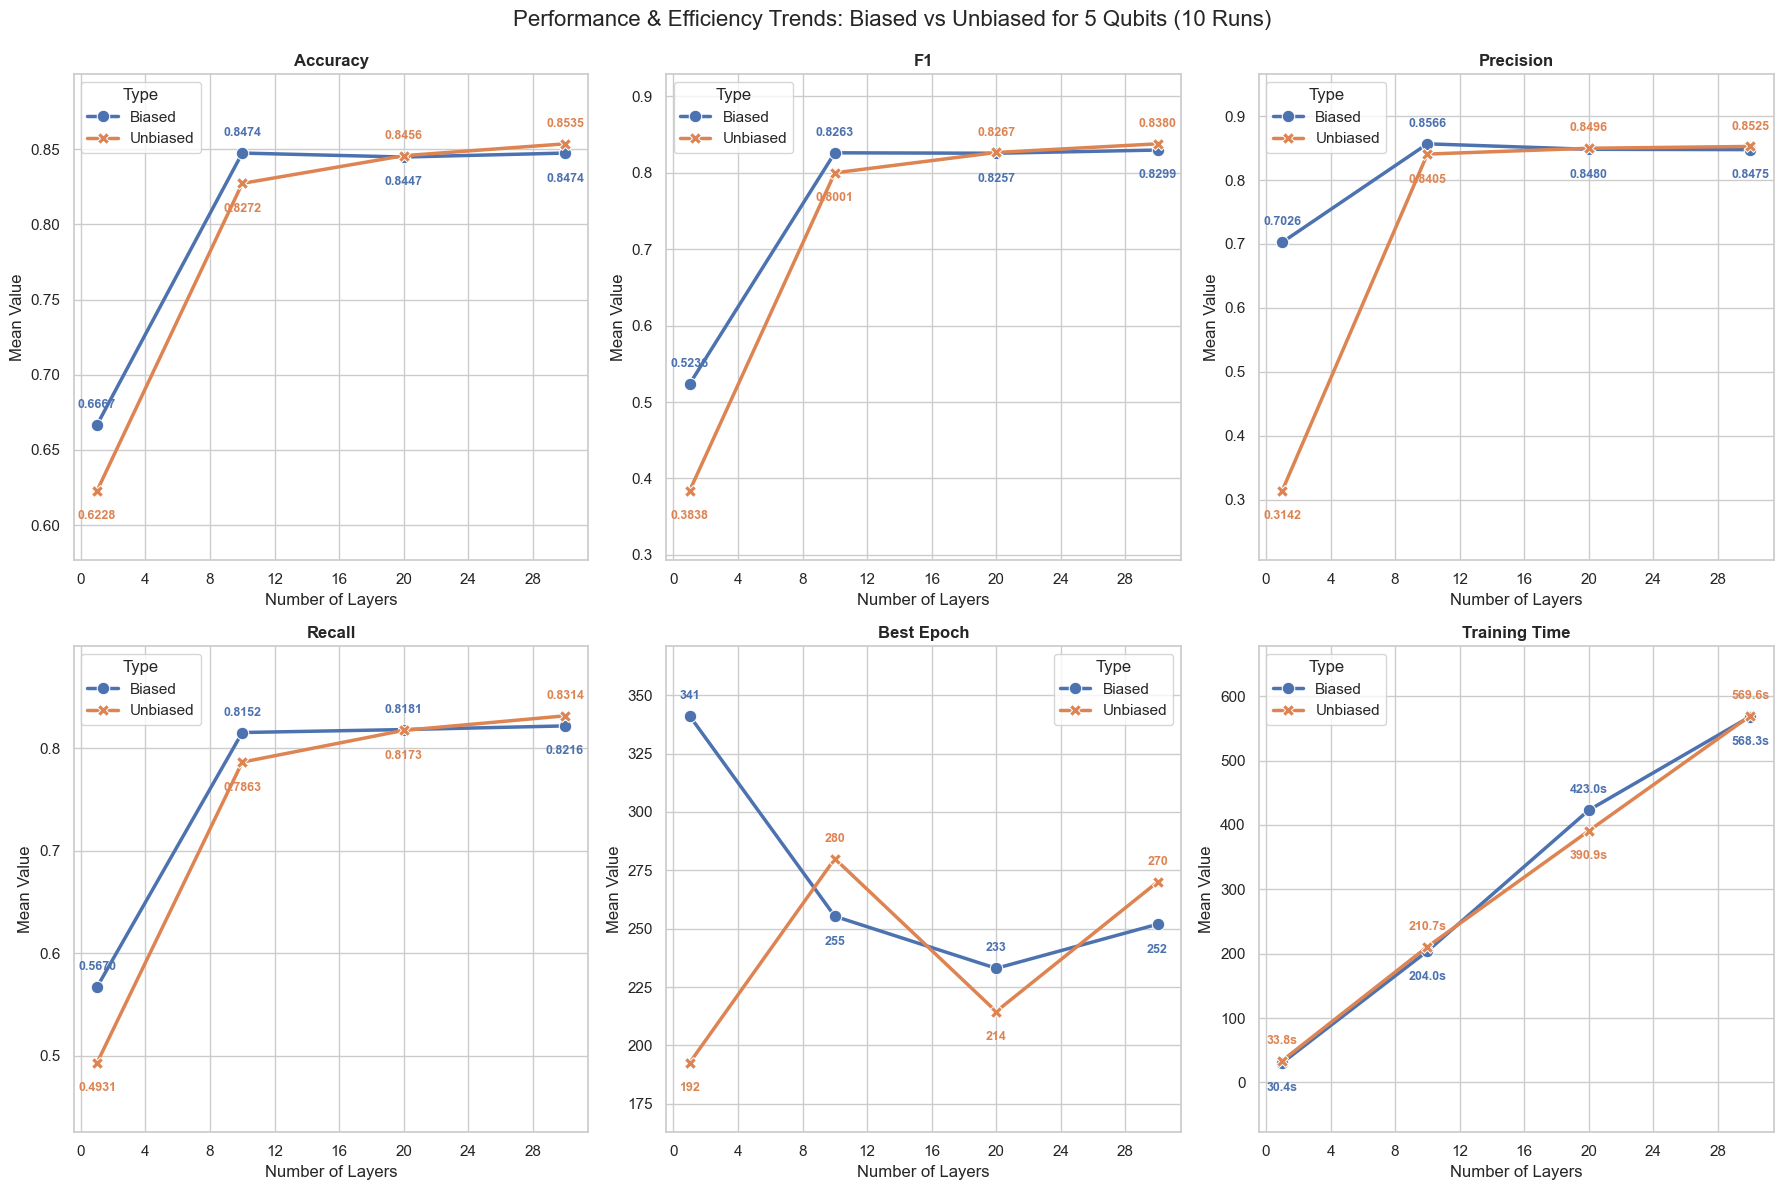

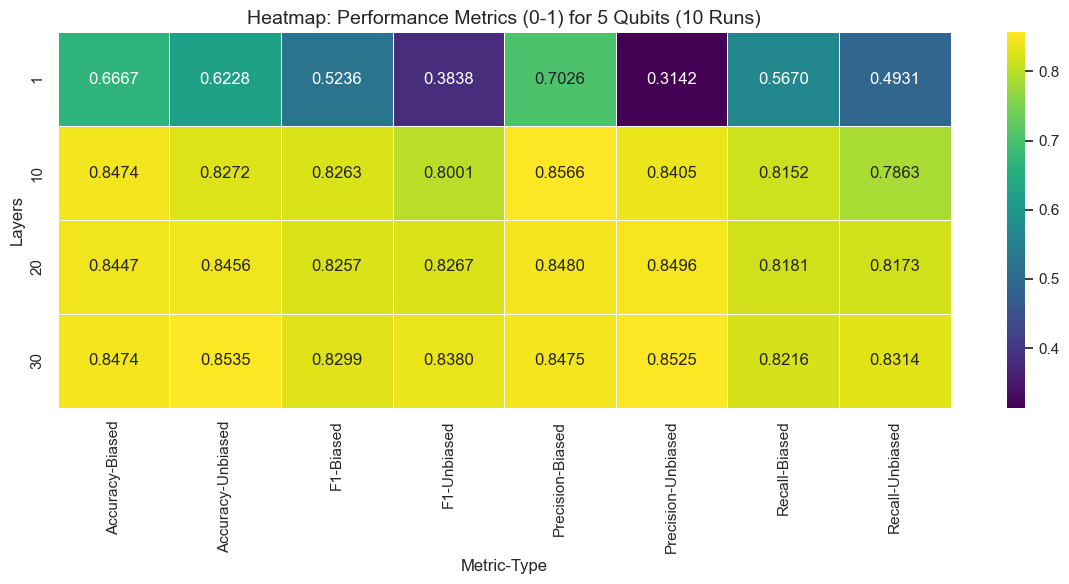

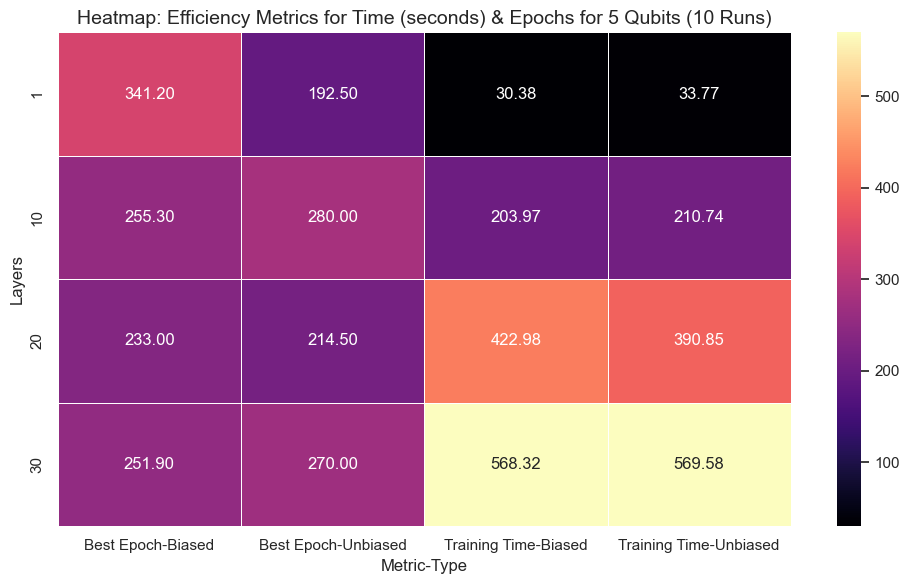

In [12]:
load_and_visualize(biased_path="./results/biased/5_qubits/metrics_dict_biased.npy",
                   unbiased_path="./results/unbiased/5_qubits/metrics_dict.npy",
                   n_qubits=5,
                   save_location="./images/10_runs/5_qubits/comparison/")

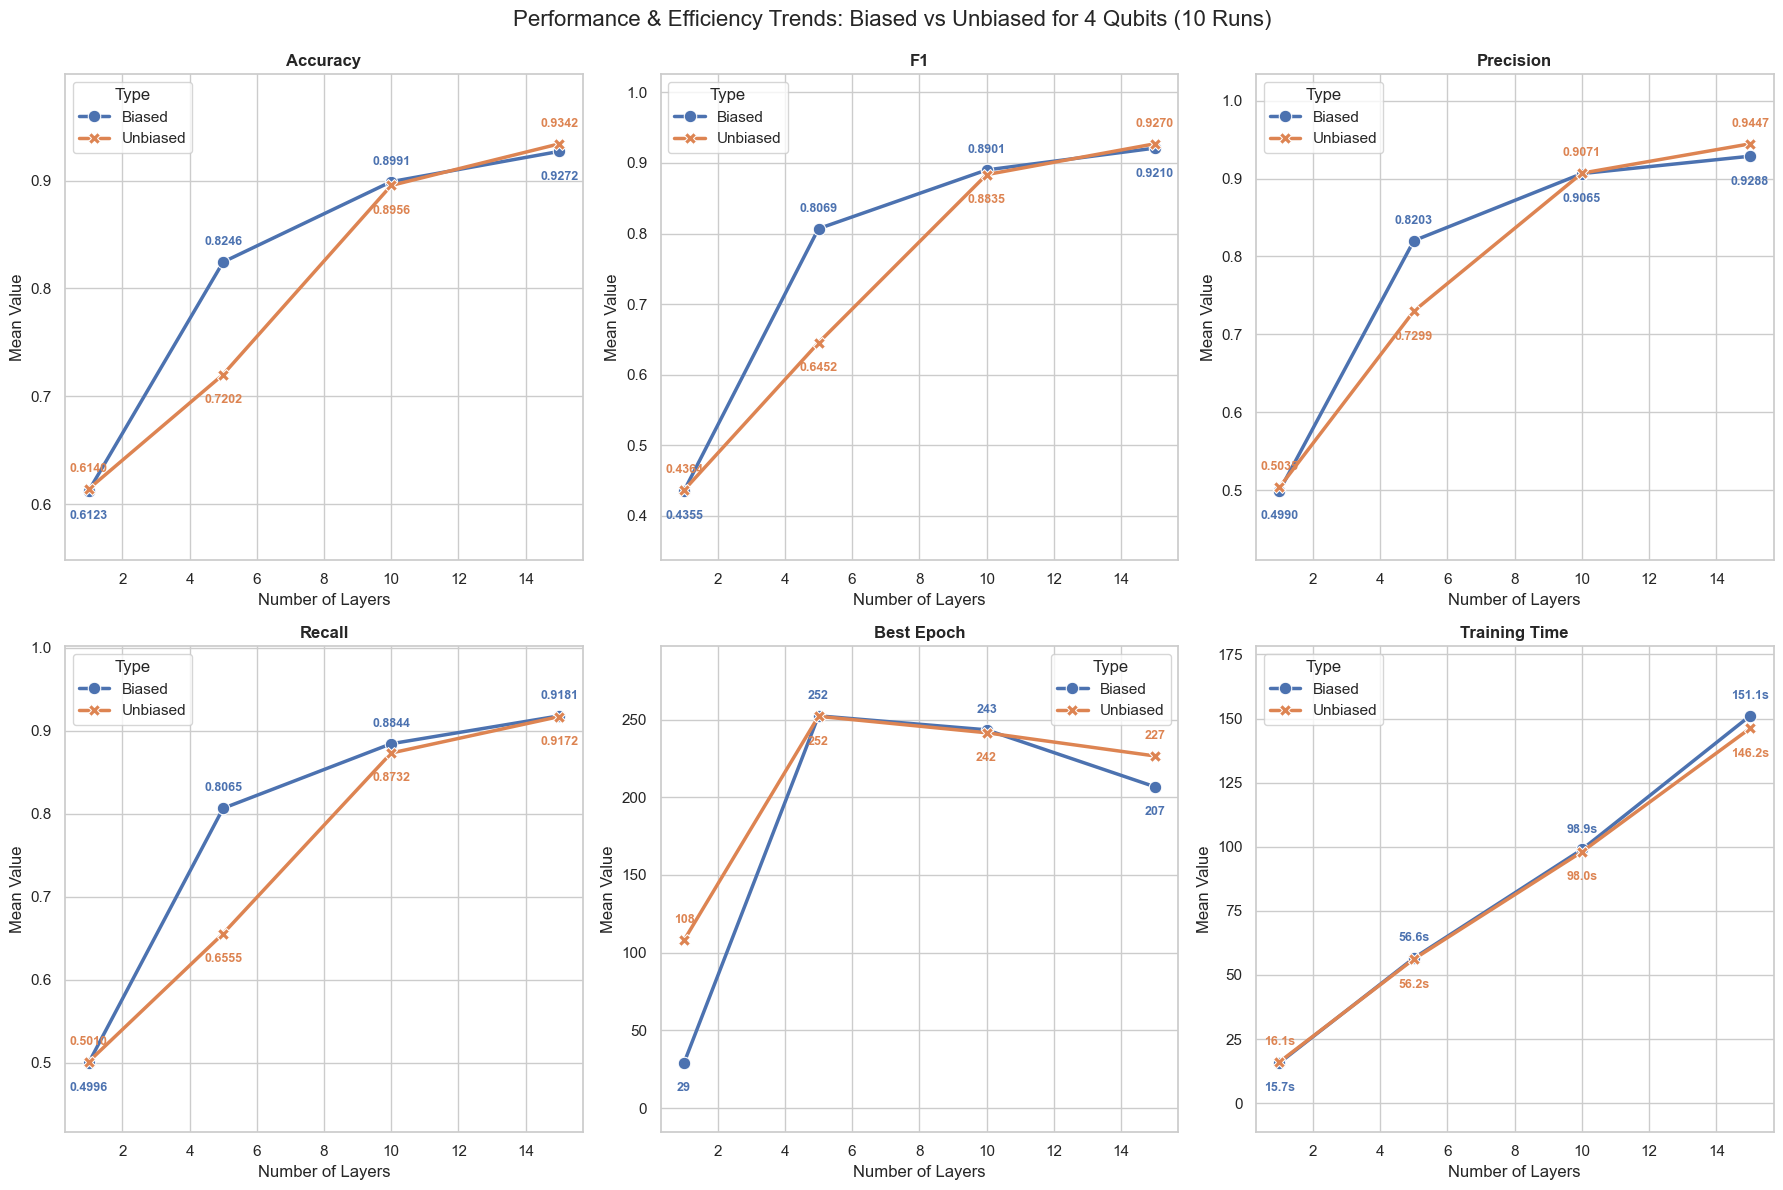

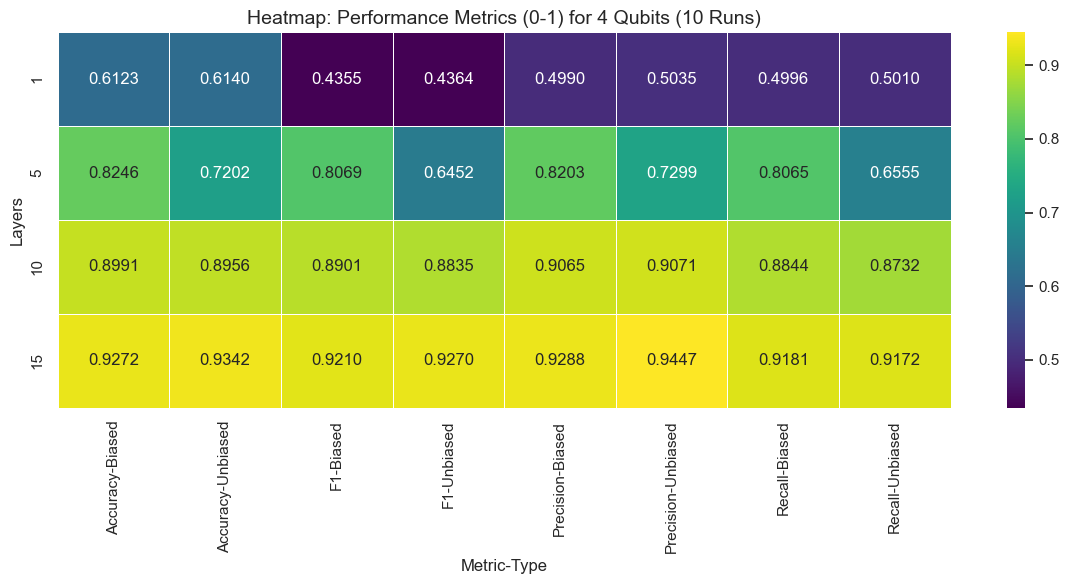

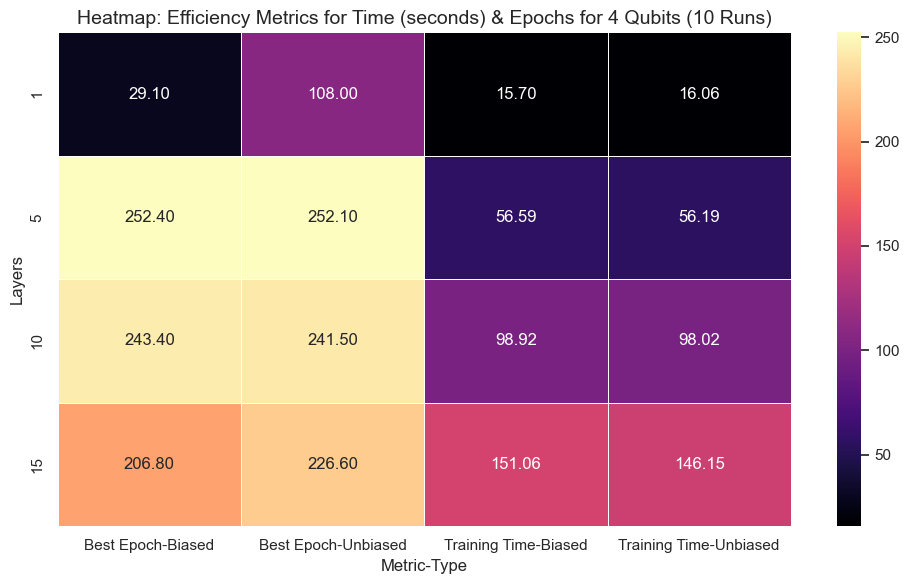

In [13]:
load_and_visualize(biased_path="./results/biased/4_qubits/metrics_dict_biased.npy",
                   unbiased_path="./results/unbiased/4_qubits/metrics_dict.npy",
                   n_qubits=4,
                   save_location="./images/10_runs/4_qubits/comparison/")

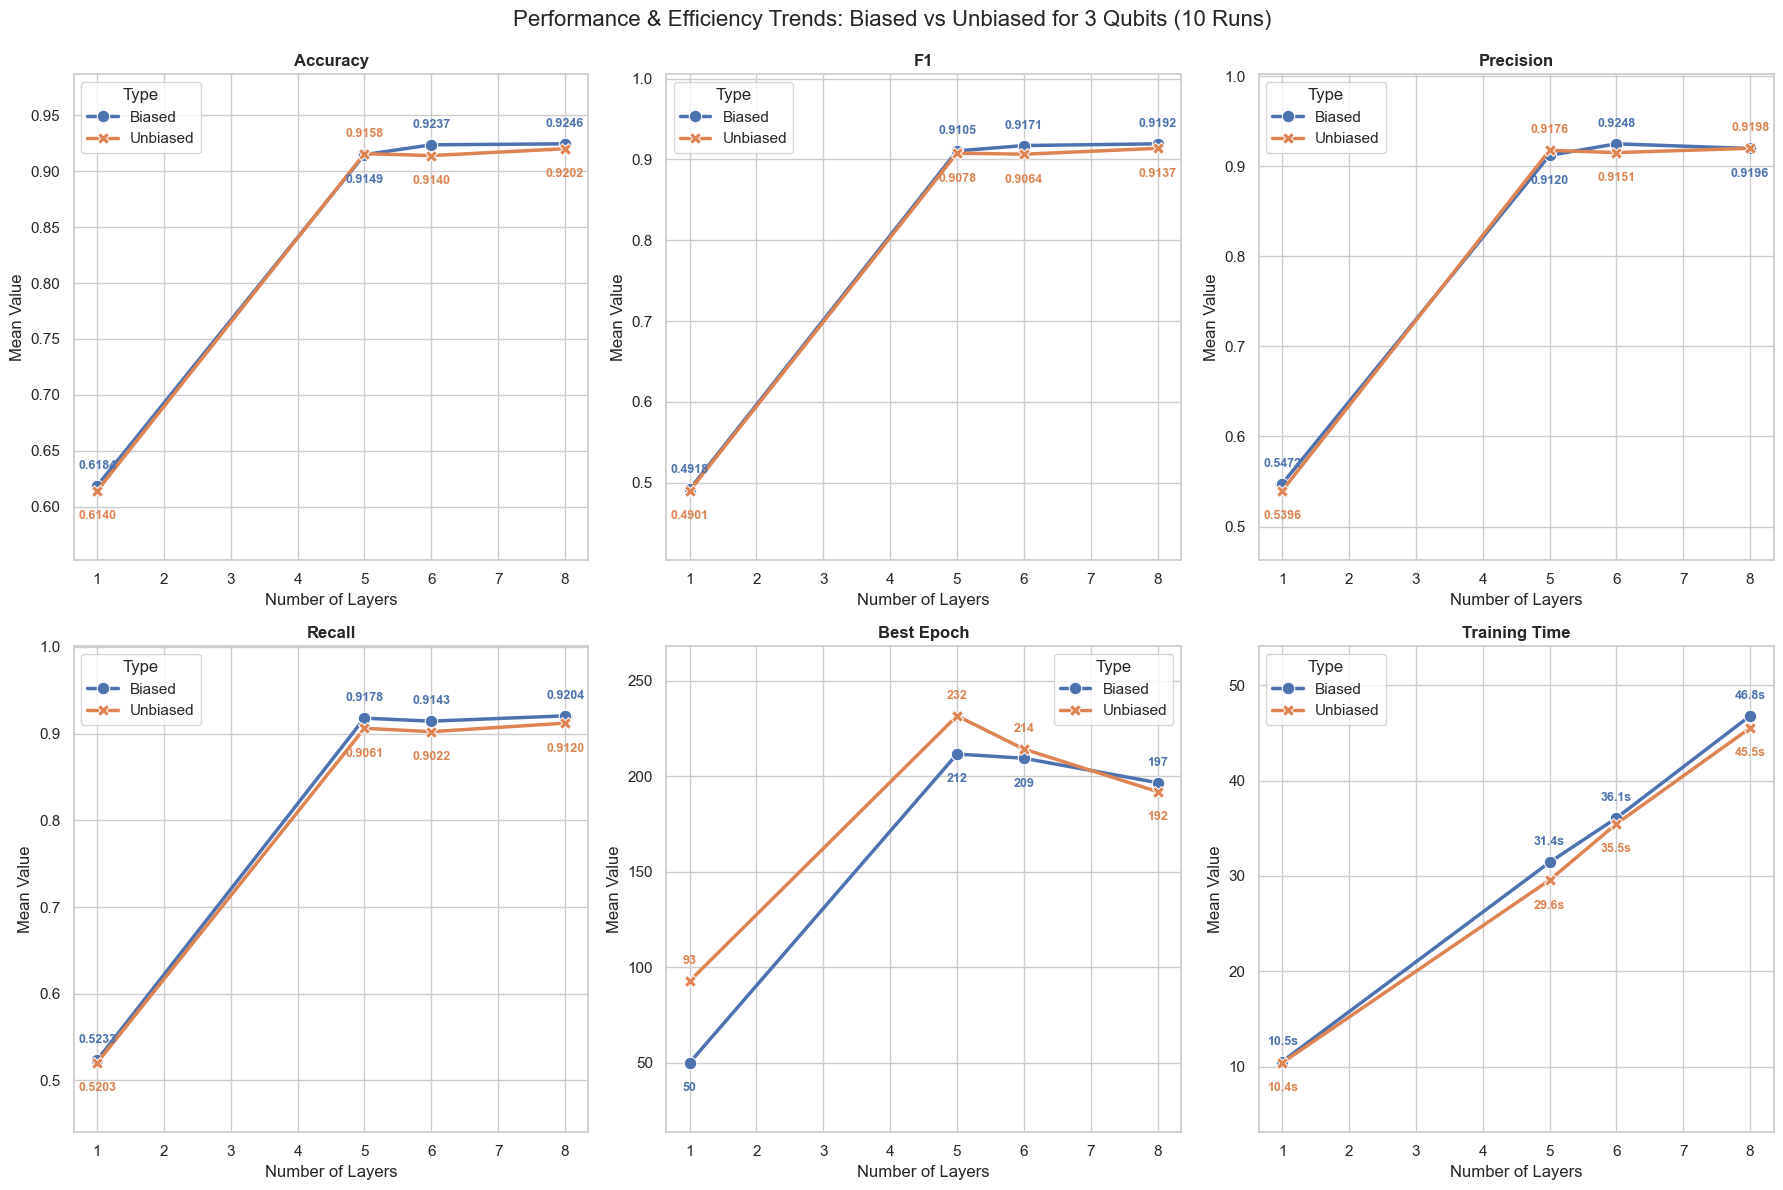

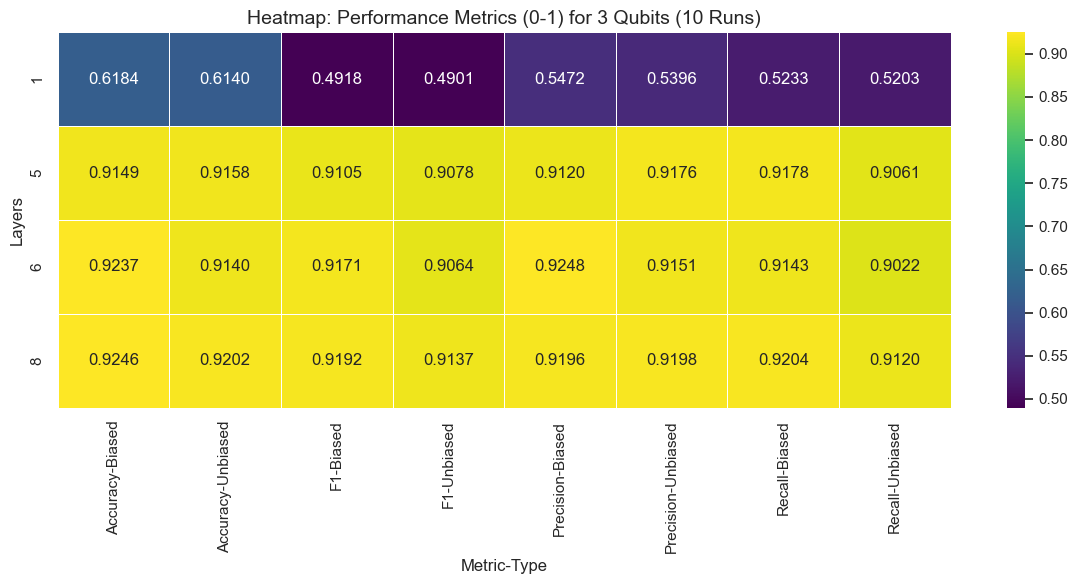

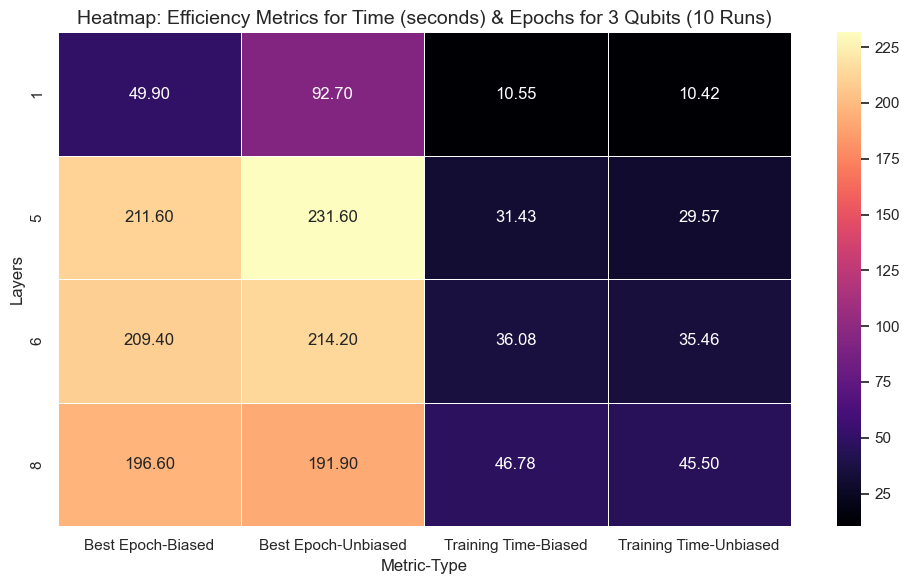

In [14]:
load_and_visualize(biased_path="./results/biased/3_qubits/metrics_dict_biased.npy",
                   unbiased_path="./results/unbiased/3_qubits/metrics_dict.npy",
                   n_qubits=3,
                   save_location="./images/10_runs/3_qubits/comparison/")

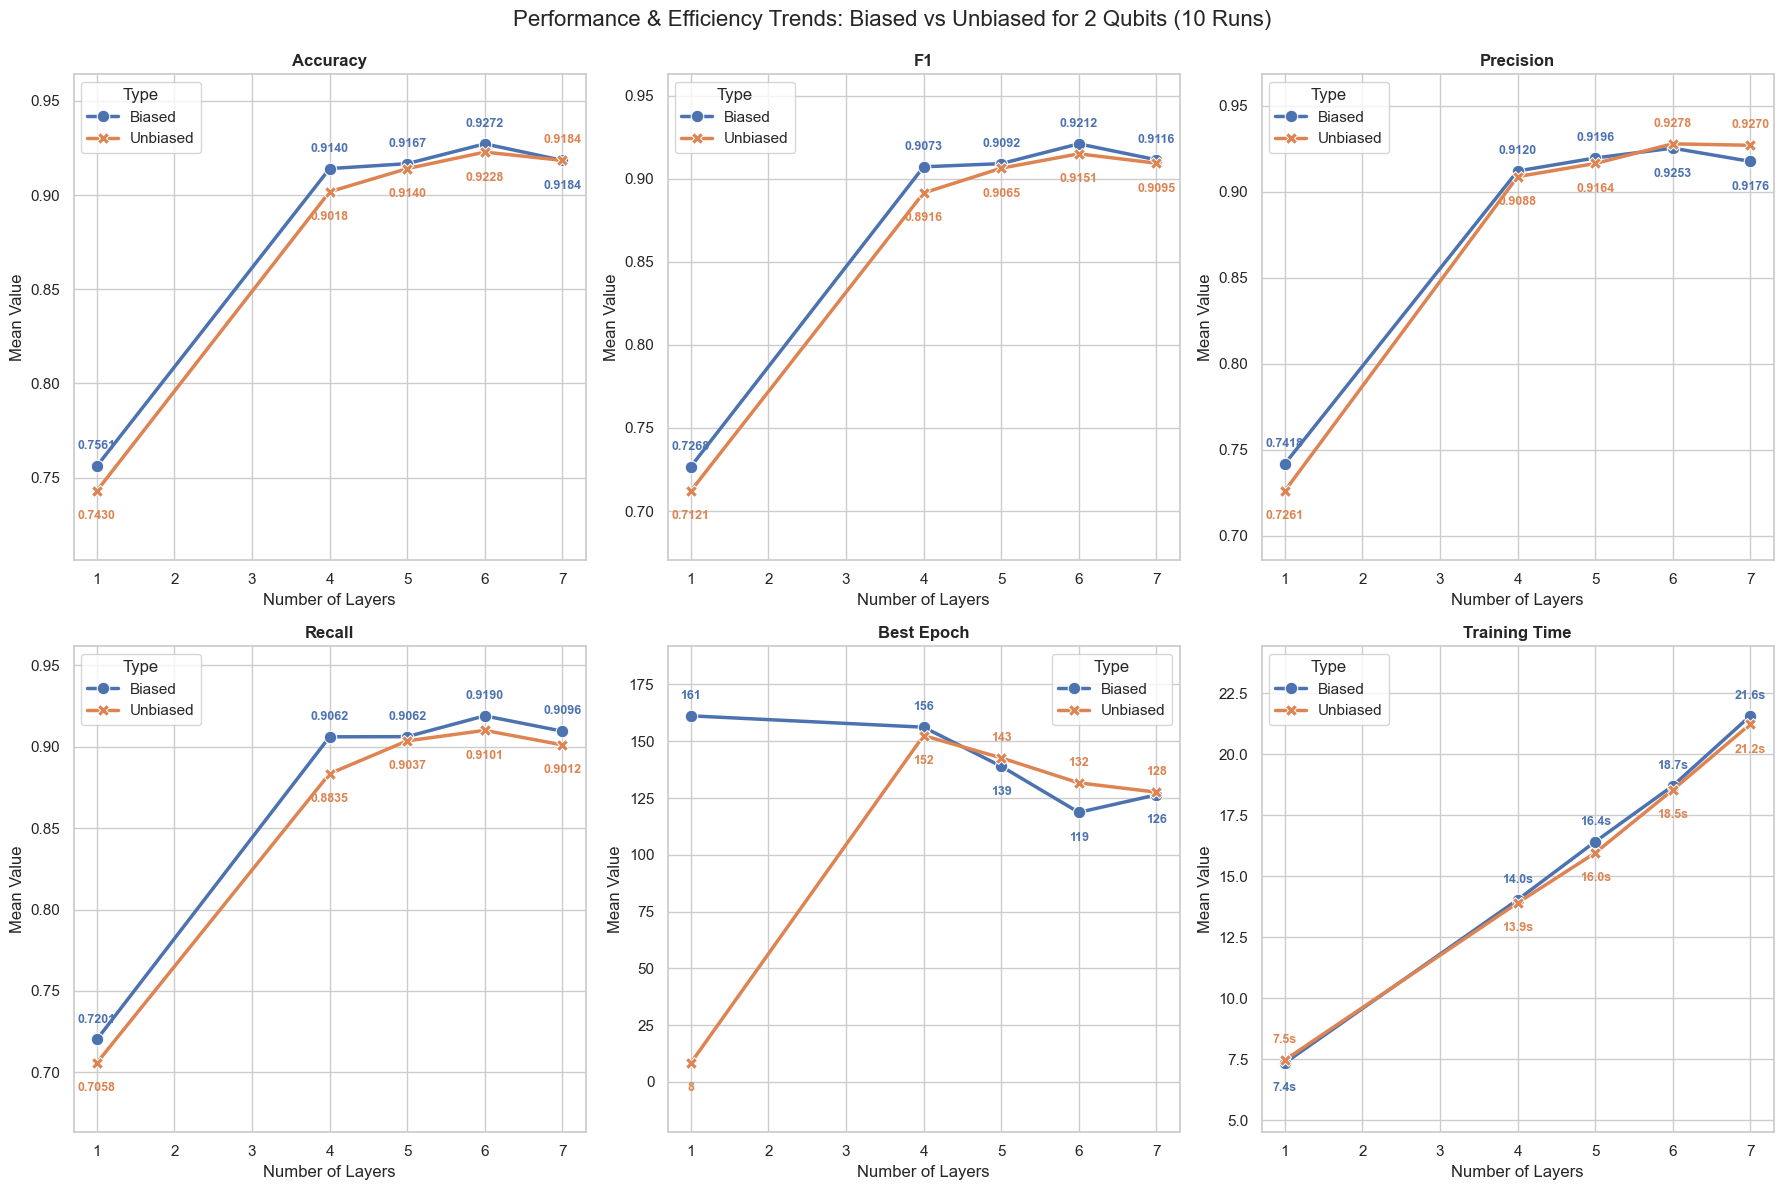

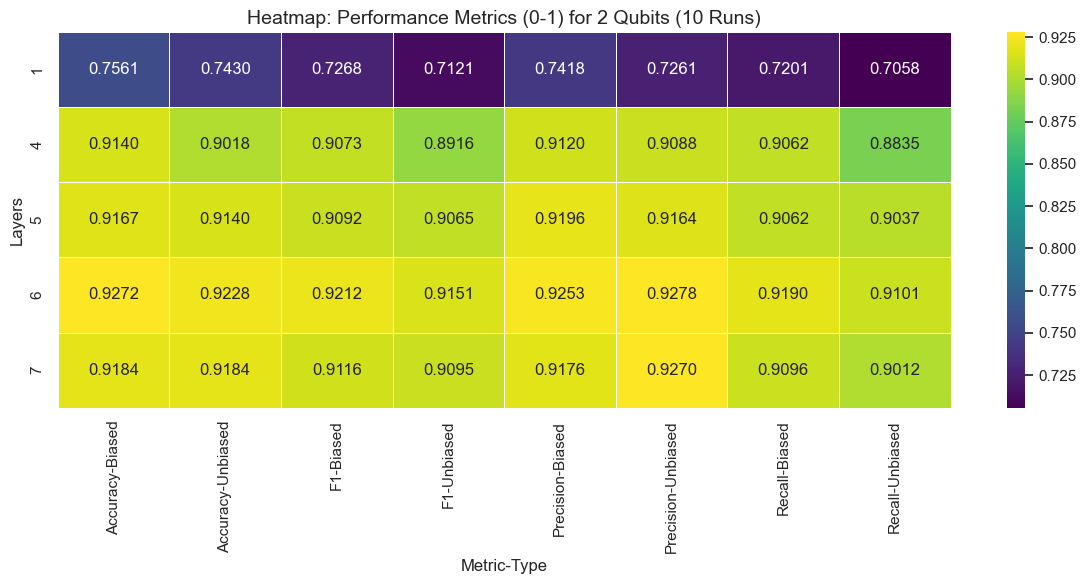

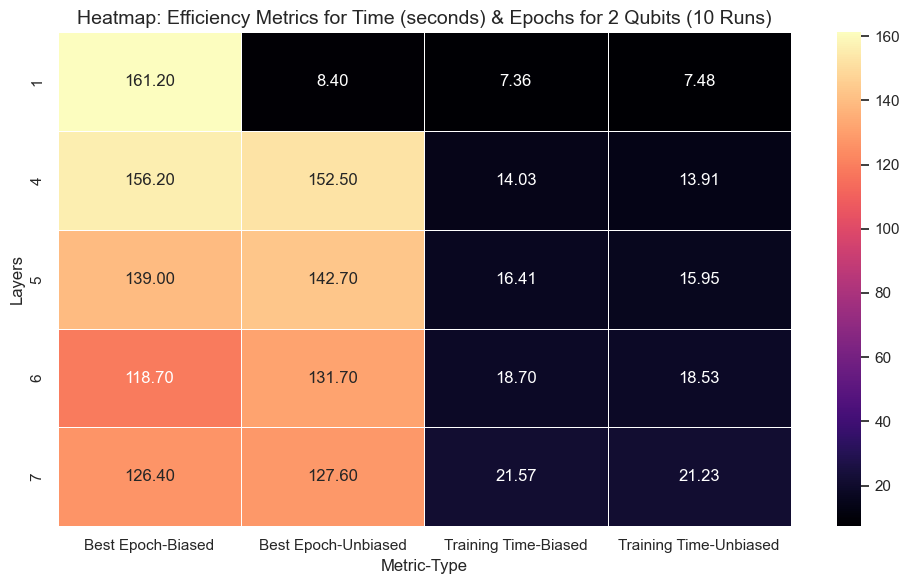

In [15]:
load_and_visualize(biased_path="./results/biased/2_qubits/metrics_dict_biased.npy",
                   unbiased_path="./results/unbiased/2_qubits/metrics_dict.npy",
                   n_qubits=2,
                   save_location="./images/10_runs/2_qubits/comparison/")

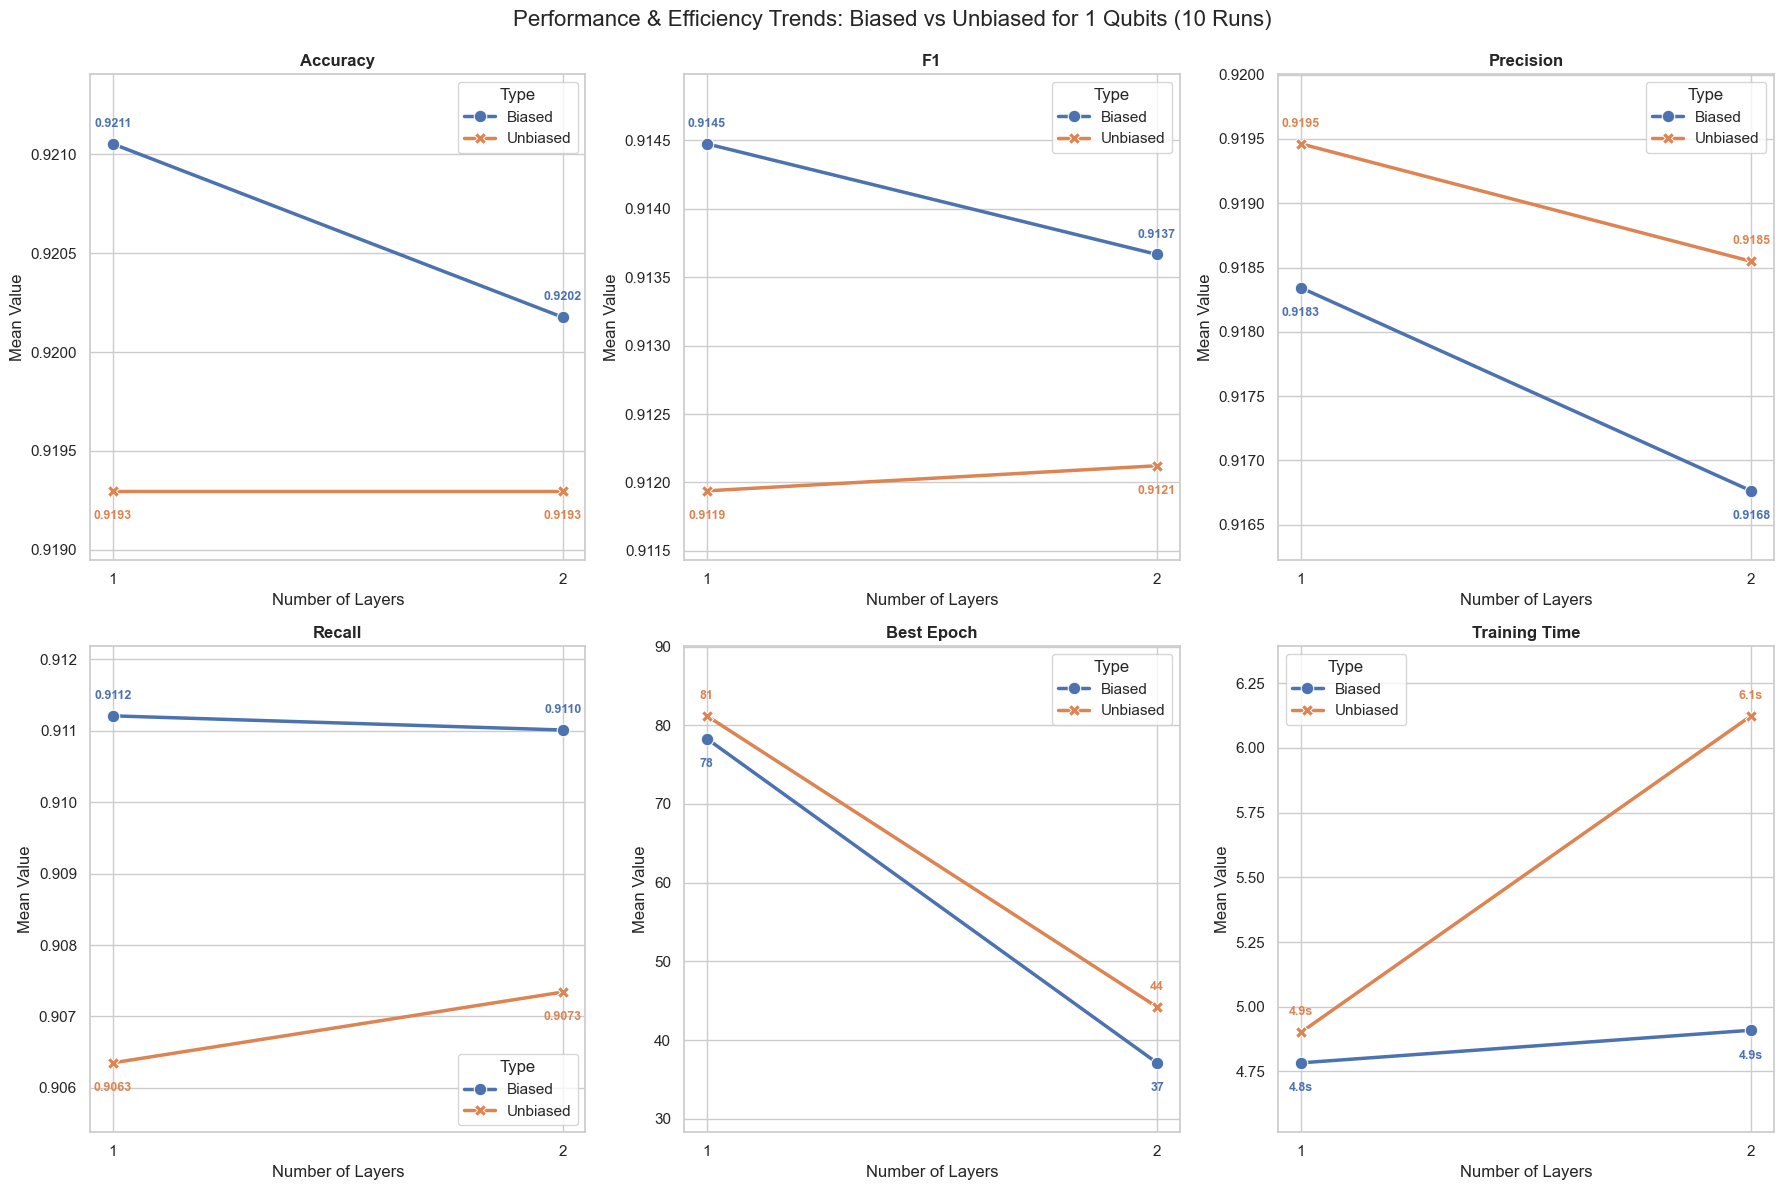

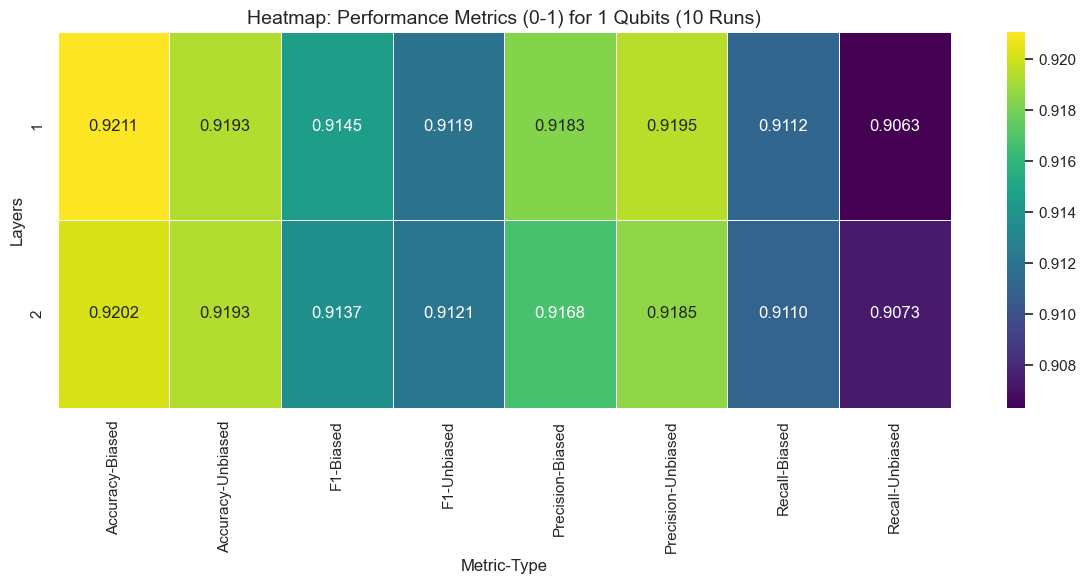

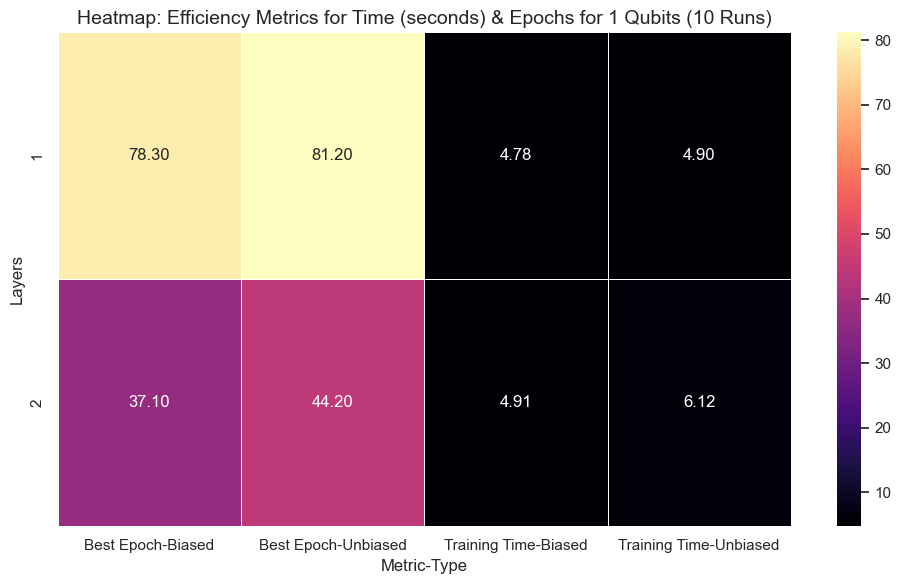

In [16]:
load_and_visualize(biased_path="./results/biased/1_qubit/metrics_dict_biased.npy",
                   unbiased_path="./results/unbiased/1_qubit/metrics_dict.npy",
                   n_qubits=1,
                   save_location="./images/10_runs/1_qubit/comparison/")

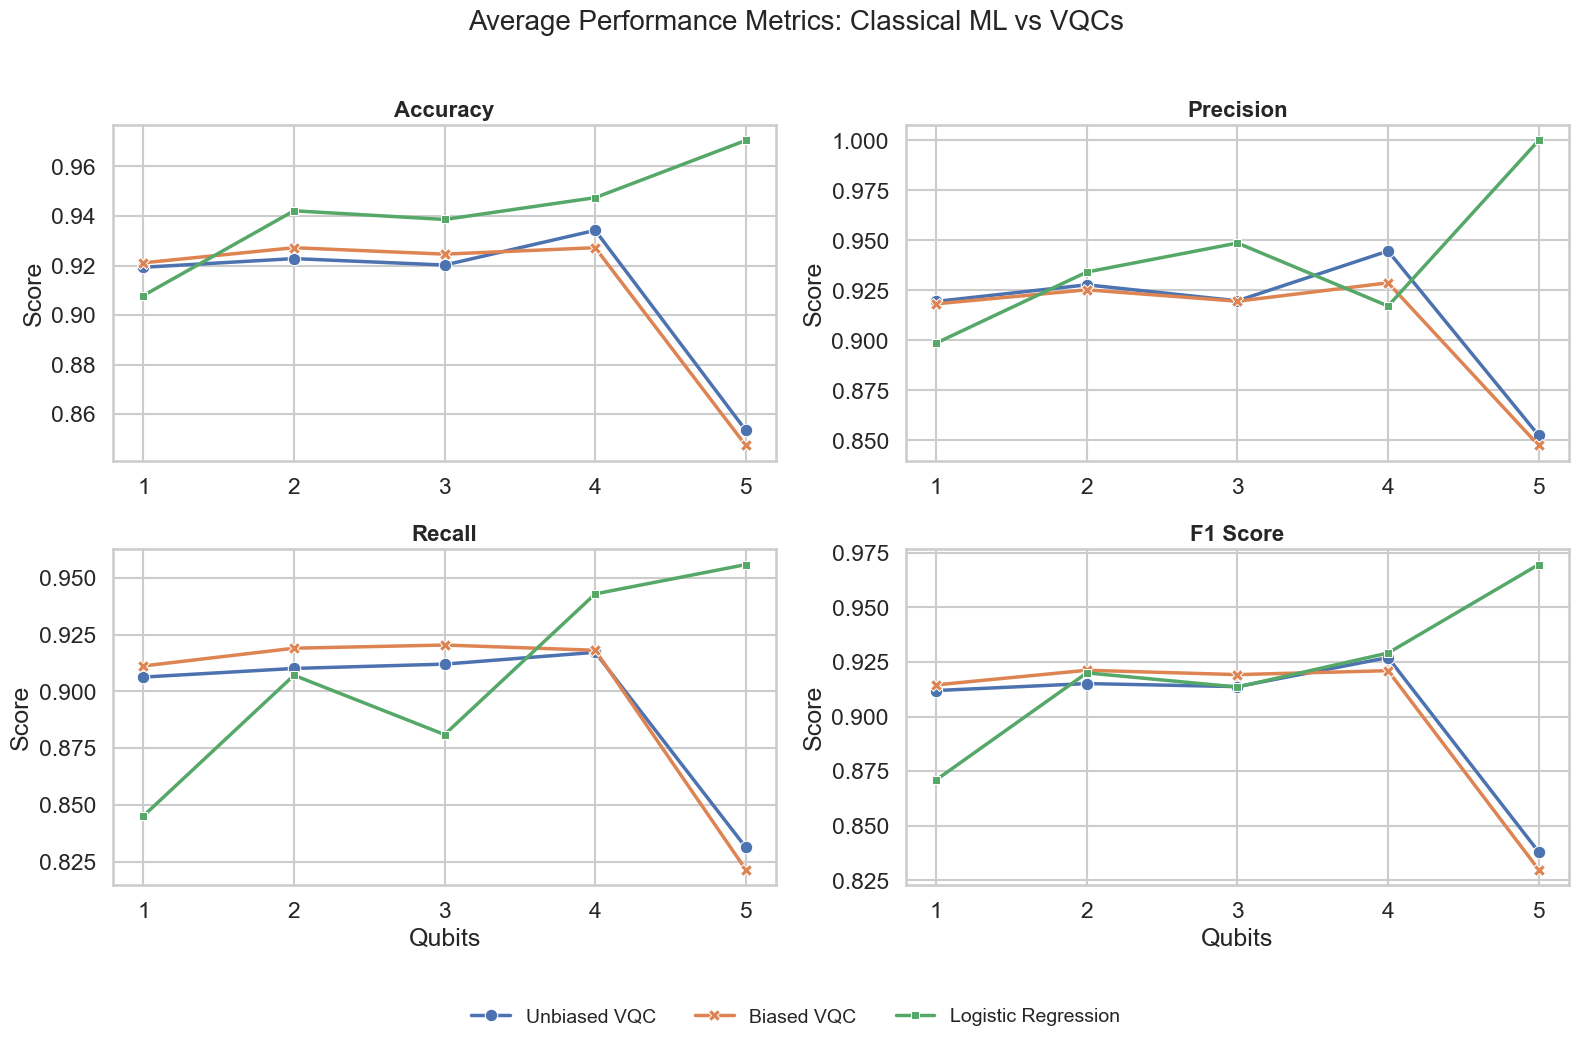

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------------
# 1. DATA PREPARATION
# -----------------------------
qubits = [1, 2, 3, 4, 5]

data_dict = {
    'Unbiased VQC': {
        'Accuracy': [0.9193, 0.9228, 0.9202, 0.9342, 0.8535],
        'Precision': [0.9195, 0.9278, 0.9198, 0.9447, 0.8525],
        'Recall': [0.9063, 0.9101, 0.9120, 0.9172, 0.8314],
        'F1 Score': [0.9119, 0.9151, 0.9137, 0.9270, 0.8380]
    },
    'Biased VQC': {
        'Accuracy': [0.9211, 0.9272, 0.9246, 0.9272, 0.8474],
        'Precision': [0.9183, 0.9253, 0.9196, 0.9288, 0.8475],
        'Recall': [0.9112, 0.9190, 0.9204, 0.9181, 0.8216],
        'F1 Score': [0.9145, 0.9212, 0.9192, 0.9210, 0.8299]
    },
    'Logistic Regression': {
        'Accuracy': [0.9079, 0.9421, 0.9386, 0.9474, 0.9705],
        'Precision': [0.8987, 0.9342, 0.9487, 0.9172, 1.0000],
        'Recall': [0.8452, 0.9071, 0.8810, 0.9429, 0.9558],
        'F1 Score': [0.8710, 0.9200, 0.9135, 0.9291, 0.9696]
    }
}

# Construct DataFrame
rows = []
for model_name, metrics in data_dict.items():
    for i, q in enumerate(qubits):
        row = {'Qubits': q, 'Model': model_name}
        for metric_name, values in metrics.items():
            row[metric_name] = values[i]
        rows.append(row)

df = pd.DataFrame(rows)

# -----------------------------
# 2. PLOTTING CONFIGURATION
# -----------------------------
sns.set_theme(style="whitegrid", context="talk") 

# FIX 1: Define palette length explicitly to match the number of models (5)
# This removes the "palette list has more values" warning
unique_models = df['Model'].unique()
palette = sns.color_palette("deep", len(unique_models))

fig, axes = plt.subplots(2, 2, figsize=(16, 11)) # Increased height slightly for legend space
axes = axes.flatten()

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# -----------------------------
# 3. PLOT GENERATION
# -----------------------------
for i, metric in enumerate(metrics_to_plot):
    sns.lineplot(
        data=df, 
        x='Qubits', 
        y=metric, 
        hue='Model', 
        style='Model',
        markers=True,
        dashes=False,
        linewidth=2.5,
        markersize=9,
        ax=axes[i],
        palette=palette,
        legend=True if i == 0 else False # Generate legend ONLY for the first plot temporarily
    )
    
    axes[i].set_title(metric, fontsize=16, weight='bold')
    axes[i].set_xlabel("Qubits" if i >= 2 else "") 
    axes[i].set_ylabel("Score")
    axes[i].set_xticks(qubits)

# -----------------------------
# 4. HANDLE LEGEND AND LAYOUT
# -----------------------------

# FIX 2: Global Legend
# Extract handles and labels from the first subplot (where we allowed the legend)
handles, labels = axes[0].get_legend_handles_labels()

# Remove the internal legend from the first subplot so it doesn't block the data
axes[0].get_legend().remove() 

# Add the Global Legend to the Figure
# loc='lower center' places it at the bottom
# bbox_to_anchor moves it slightly below the plots
# ncol=5 spreads the items horizontally
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=5, frameon=False, fontsize=14)

plt.suptitle('Average Performance Metrics: Classical ML vs VQCs', fontsize=20, y=0.96)

# Adjust layout: 'rect' creates space at the bottom for the legend
# [left, bottom, right, top]
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig('./images/10_runs/final_comparison/vqc_vs_classical.png',dpi=300, bbox_inches='tight')
plt.show()